In [4]:
from glob import glob
import pandas as pd
from scipy.stats import levene
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
import scikit_posthocs as sp
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [8]:

def adapt_nested_cv_metrics(
    csvfile,
    outer_fold_col="outer_fold",
    inner_fold_col="inner_fold",
    split_col="split",
    n_inner=5,
):
    """
    Adapter for precomputed nested-CV regression metrics.

    """
    df = pd.read_csv(csvfile)
    df = df.copy()

    # --- matrix-style cv_cycle ---
    df["cv_cycle"] = (
        (df[outer_fold_col] - 1) * n_inner
        + (df[inner_fold_col] - 1)
    )

    if "basename" in df.columns:
        col = "basename"
        ext = ".pt"
    elif "model_file" in df.columns:
        col = "model_file"
        ext = ".rds"
    else:
        raise ValueError("Neither 'basename' nor 'model_file' found in dataframe")

    # Remove extension
    base = df[col].str.replace(ext, "", regex=False)

    # Remove the training / split / fold block
    # matches: _1_train_butina_fold1, _1_train_random_fold3, etc.
    base = base.str.replace(
        r"_\d+_train_[^_]+_fold\d+",
        "",
        regex=True,
    )

    df["method"] = base    

    # --- return: metrics untouched ---
    return df[
        [
            "cv_cycle",
            "method",
            split_col,
            "R2",
            "RMSE",
            "MAE",
            "PearsonR",
            "SpearmanRho",
        ]
    ]

def concat_metric_files(csv_files):
    
    files = []
    for path in csv_files:
        files.extend(sorted(glob(path)))
    if not files:
        raise ValueError(f"No CSV files matched pattern: {csv_files}")
    
    df_list = []
    for csv_file in files:
        df_tmp = adapt_nested_cv_metrics(csv_file)
        df_list.append(df_tmp)
    return pd.concat(df_list, ignore_index=True)

def variance_analysis_by_split(
    df,
    metric_cols,
    split_col="split",
    method_col="method",
):
    """
    Compute variance instability diagnostics across methods.

    Returns a tidy dataframe with:
      split | metric | levene_pvalue | max_over_min
    """

    records = []

    for split_name, df_split in df.groupby(split_col):
        for metric in metric_cols:
            # collect per-method metric lists
            groups = (
                df_split
                .groupby(method_col)[metric]
                .apply(list)
                .dropna()
            )

            # --- Levene p-value ---
            if len(groups) >= 2:
                _, pval = levene(*groups)
            else:
                pval = None

            # --- Variance ratio ---
            variances = (
                df_split
                .groupby(method_col)[metric]
                .var()
                .dropna()
            )

            if len(variances) >= 2 and variances.min() > 0:
                max_over_min = variances.max() / variances.min()
            else:
                max_over_min = None

            records.append({
                "split": split_name,
                "metric": metric,
                "levene_pvalue": pval,
                "max_over_min": max_over_min,
            })

    return pd.DataFrame(records)

def extract_common_prefix(strings, sep="_"):
    """
    Extract common prefix across strings split by `sep`.
    """
    if len(strings) < 2:
        return ""

    split_strings = [s.split(sep) for s in strings]
    common = []

    for tokens in zip(*split_strings):
        if all(t == tokens[0] for t in tokens):
            common.append(tokens[0])
        else:
            break

    return sep.join(common)


def make_boxplots_parametric(
    df,
    metric_ls,
    method_col="method",
    subject_col="cv_cycle",
    prefix="spliting",
    outdir=None,
):
    """
    Parametric boxplots using repeated-measures ANOVA with automatic
    redundancy removal in method labels.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns:
        - method_col (e.g. model / architecture name)
        - subject_col (e.g. cv_cycle)
        - metrics in metric_ls
    metric_ls : list[str]
        Metrics to plot
    method_col : str
        Column indicating method / model
    subject_col : str
        Repeated-measures subject identifier

    Returns
    -------
    None
    """

    sns.set_context("notebook")
    sns.set_style("whitegrid")

    n_metrics = len(metric_ls)
    fig, axes = plt.subplots(
        1, n_metrics, figsize=(6 * n_metrics, 6), sharey=False
    )

    if n_metrics == 1:
        axes = [axes]

    # --- Detect redundant text in method names ---
    methods = df[method_col].unique().tolist()
    common_prefix = extract_common_prefix(methods)

    # Clean title-friendly version
    title_prefix = (
        (common_prefix.replace("_", " ").replace("-", " ").strip() + "\n" +prefix)
        if common_prefix
        else None
    )

    for ax, metric in zip(axes, metric_ls):

        # --- Repeated-measures ANOVA ---
        try:
            model = AnovaRM(
                data=df,
                depvar=metric,
                subject=subject_col,
                within=[method_col],
                aggregate_func="mean",  # fixes duplicate obs warning
            ).fit()
            p_value = model.anova_table["Pr > F"].iloc[0]
            p_text = f"ANOVA p={p_value:.1e}"
        except Exception as e:
            print(f"Warning: ANOVA failed for {metric}: {e}")
            p_text = "ANOVA failed"

        # --- Boxplot ---
        sns.boxplot(
            data=df,
            x=method_col,
            y=metric,
            hue=method_col,
            dodge=False,
            palette="Set2",
            ax=ax,
            legend=False,
        )

        if title_prefix:
            fig.suptitle(
                title_prefix.replace("_", " ").replace("-", " "),
                fontsize=18 #,
                # y=1.02
            )

        # --- Per-axis title ---
        ax.set_title(f"{metric.upper()}\n{p_text}", fontsize=14)

        # --- Shorten x tick labels ---
        x_labels = [t.get_text() for t in ax.get_xticklabels()]
        short_labels = []

        for label in x_labels:
            if common_prefix and label.startswith(common_prefix):
                short = label[len(common_prefix):].lstrip("_")
            else:
                short = label
            short_labels.append(short)

        ax.set_xticks(range(len(short_labels)))
        ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=16)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
        ax.set_xlabel("")
        ax.set_ylabel(metric, fontsize=16)
 

    plt.tight_layout()
    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
    plt.savefig(outdir / ("parameteric_box_plots_" + common_prefix.replace("-", "_").strip() + "_" + prefix + ".png"), dpi=300)
    # plt.show()

def make_boxplots_nonparametric(
    df,
    metric_ls,
    method_col="method",
    subject_col="cv_cycle",
    prefix="spliting",
    outdir=None,
):
    """
    Non-parametric boxplots using Friedman test with automatic
    redundancy removal in method labels.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns:
        - method_col (e.g. model / architecture name)
        - subject_col (e.g. cv_cycle)
        - metrics in metric_ls
    metric_ls : list[str]
        Metrics to plot
    method_col : str
        Column indicating method / model
    subject_col : str
        Repeated-measures subject identifier

    Returns
    -------
    None
    """

    sns.set_context("notebook")
    sns.set_style("whitegrid")

    n_metrics = len(metric_ls)
    fig, axes = plt.subplots(
        1, n_metrics, figsize=(6 * n_metrics, 6), sharey=False
    )

    if n_metrics == 1:
        axes = [axes]

    # --- Detect redundant text in method names ---
    methods = df[method_col].unique().tolist()
    common_prefix = extract_common_prefix(methods)

    # Clean title-friendly version
    title_prefix = (
        (common_prefix.replace("_", " ").replace("-", " ").strip() + "\n" + prefix)
        if common_prefix
        else None
    )

    for ax, metric in zip(axes, metric_ls):

        # --- Friedman test ---
        try:
            friedman = pg.friedman(
                data=df,
                dv=metric,
                within=method_col,
                subject=subject_col
            )
            p_value = friedman["p-unc"].iloc[0]
            p_text = f"Friedman p={p_value:.1e}"
        except Exception as e:
            print(f"Warning: Friedman failed for {metric}: {e}")
            p_text = "Friedman failed"

        # --- Boxplot ---
        sns.boxplot(
            data=df,
            x=method_col,
            y=metric,
            hue=method_col,
            dodge=False,
            palette="Set2",
            ax=ax,
            legend=False,
        )

        ax.set_ylim([0,1])

        if title_prefix:
            fig.suptitle(
                title_prefix.replace("_", " ").replace("-", " "),
                fontsize=18) #,
                #y=1.02
            #)

        # --- Per-axis title ---
        ax.set_title(f"{metric.upper()}\n{p_text}", fontsize=14)

        # --- Shorten x tick labels ---
        x_labels = [t.get_text() for t in ax.get_xticklabels()]
        short_labels = []

        for label in x_labels:
            if common_prefix and label.startswith(common_prefix):
                short = label[len(common_prefix):].lstrip("_")
            else:
                short = label
            short_labels.append(short)

        ax.set_xticks(range(len(short_labels)))
        ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=16)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
        ax.set_xlabel("")
        ax.set_ylabel(metric, fontsize=16)

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(outdir / ("non_parameteric_box_plots_" + common_prefix.replace("-", "_").strip() + "_" + prefix + ".png"), dpi=300)
    # plt.show()


def make_sign_plots_nonparametric(
    df,
    metric_ls,
    method_col="method",
    subject_col="cv_cycle",
    prefix="spliting",
    outdir=None,
):
    """
    Non-parametric significance plots using Friedman + Conover post-hoc
    with automatic redundancy removal in method labels.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
        - method_col
        - subject_col
        - metrics in metric_ls
    metric_ls : list[str]
        Metrics to plot
    method_col : str
        Column with model / method names
    subject_col : str
        Repeated-measures identifier
    prefix : str
        Extra text appended to the shared title
    """

    sns.set_context("notebook")
    sns.set_style("whitegrid")

    heatmap_args = {
        "linewidths": 0.25,
        "linecolor": "0.5",
        "clip_on": True,
        "square": True,
    }

    n_metrics = len(metric_ls)
    fig, axes = plt.subplots(
        1, n_metrics, figsize=(5 * n_metrics, 6), sharey=True
    )

    if n_metrics == 1:
        axes = [axes]

    # --- Detect redundant text in method names ---
    methods = df[method_col].unique().tolist()
    common_prefix = extract_common_prefix(methods)

    # --- Shared title ---
    title_prefix = (
        (common_prefix.replace("_", " ").replace("-", " ").strip() + "\n" + prefix)
        if common_prefix
        else prefix
    )

    fig.suptitle(title_prefix, fontsize=18) #, y=1.05)

    for ax, metric in zip(axes, metric_ls):

        # --- Pivot for Friedman / Conover ---
        pivot_df = df.pivot(
            index=subject_col,
            columns=method_col,
            values=metric
        )

        # --- Post-hoc Conover after Friedman ---
        pc = sp.posthoc_conover_friedman(
            pivot_df,
            p_adjust="holm"
        )

        # --- Significance plot ---
        sub_ax, _ = sp.sign_plot(
            pc,
            ax=ax,
            xticklabels=True,
            **heatmap_args,
        )

        # --- Shorten tick labels ---
        labels = [t.get_text() for t in sub_ax.get_xticklabels()]
        short_labels = []

        for label in labels:
            if common_prefix and label.startswith(common_prefix):
                short = label[len(common_prefix):].lstrip("_")
            else:
                short = label
            short_labels.append(short)

        sub_ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=14)
        sub_ax.set_yticklabels(short_labels, fontsize=14)

        # --- Axis title ---
        sub_ax.set_title(metric.upper(), fontsize=16)

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
    # plt.tight_layout()
    plt.savefig(outdir / ("non_parameteric_sign_plots_" + common_prefix.replace("-", "_").strip() + "_" + prefix + ".png"), dpi=300)
    # plt.show()

from openpyxl import load_workbook
from openpyxl.styles import Font
from openpyxl.utils import get_column_letter


def export_levene_results_to_excel(
    memb_csv_files,
    output_excel="Levene_variance_results.xlsx",
    metric_ls_full=None,
    float_format="%.3g",
    sheet_name="Levene_variance"
):
    if metric_ls_full is None:
        metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']

    # --- First write everything with pandas ---
    startrow = 0
    with pd.ExcelWriter(output_excel, engine="openpyxl", mode="w") as writer:
        for csv_file in memb_csv_files:
            # --- Run analysis ---
            df = concat_metric_files(csv_file)
            levene_df = variance_analysis_by_split(df, metric_ls_full)

            # --- Table title ---
            title = Path(csv_file[0]).stem

            # --- Write title row ---
            pd.DataFrame([[title]]).to_excel(
                writer,
                sheet_name=sheet_name,
                startrow=startrow,
                index=False,
                header=False
            )

            # --- Write table ---
            levene_df.to_excel(
                writer,
                sheet_name=sheet_name,
                startrow=startrow + 1,
                index=False,
                float_format=float_format
            )

            # --- Advance row counter (title + table + spacer) ---
            startrow += len(levene_df) + 3

    # --- Post-process formatting with openpyxl ---
    wb = load_workbook(output_excel)
    ws = wb[sheet_name]

    current_row = 1
    for csv_file in memb_csv_files:
        title = Path(csv_file[0]).stem

        # Determine table width from header row
        max_col = ws.max_column
        ws.merge_cells(
            start_row=current_row,
            start_column=1,
            end_row=current_row,
            end_column=max_col
        )

        cell = ws.cell(row=current_row, column=1)
        cell.font = Font(bold=True)

        # Move to next table title
        df = concat_metric_files(csv_file)
        levene_df = variance_analysis_by_split(df, metric_ls_full)
        current_row += len(levene_df) + 3

    # --- Auto-adjust column widths ---
    for col in ws.columns:
        max_len = max(len(str(cell.value)) if cell.value is not None else 0 for cell in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = max_len + 2

    wb.save(output_excel)

In [3]:
adapt_nested_cv_metrics("../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol.csv")#, model_file_col="basename")


,cv_cycle,method,split,R2,RMSE,MAE,PearsonR,SpearmanRho
0,0,popc_chol-biogen-P_app_lgfe_arch1_FCNN,butina,0.237773,0.582693,0.463249,0.494261,0.525062
1,0,popc_chol-biogen-P_app_lgfe_arch2_FCNN,butina,0.254082,0.576425,0.459976,0.506094,0.555515
2,0,popc_chol-biogen-P_app_lgfe_arch3_FCNN,butina,0.263162,0.572906,0.444921,0.520924,0.554559
3,0,popc_chol-biogen-P_app_lgfe_arch4_FCNN,butina,0.239083,0.582192,0.448628,0.507266,0.519636
4,0,popc_chol-biogen-P_app_lgfe_arch5_FCNN,butina,0.267082,0.571380,0.446922,0.527824,0.552222
...,...,...,...,...,...,...,...,...
370,24,popc_chol-biogen-P_app_lgfe_arch1_FCNN,scaffold,0.252826,0.592896,0.445715,0.530883,0.546738
371,24,popc_chol-biogen-P_app_lgfe_arch2_FCNN,scaffold,0.263149,0.588786,0.440469,0.528108,0.536216
372,24,popc_chol-biogen-P_app_lgfe_arch3_FCNN,scaffold,0.305988,0.571414,0.446624,0.556658,0.566646
373,24,popc_chol-biogen-P_app_lgfe_arch4_FCNN,scaffold,0.257231,0.591146,0.457502,0.526127,0.550326


### P_app prediction with Hybrid LGFE profiles

#### 1. FCNN

In [ ]:
csv_files = ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol.csv"]
             # "../ml-modeling-P_app_lgfe_biogen_base/evaluation/XGBoost/*.csv",
             # "../ml-modeling-P_app_lgfe_biogen_base/evaluation/LightGBM/*.csv"]
            # "../ml-modeling-P_app_lgfe_biogen_base/evaluation/SVM_rbf/*.csv",
            # "../ml-modeling-P_app_lgfe_biogen_base/evaluation/Lasso/*.csv"]

In [6]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol_halogen.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_pampa.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_bbb.csv"]]


In [9]:
export_levene_results_to_excel(
    memb_csv_files,
    output_excel="Levene_variance_results.xlsx"
)

In [5]:
test_df = concat_metric_files(csv_files)
test_df

,cv_cycle,method,split,R2,RMSE,MAE,PearsonR,SpearmanRho
0,0,popc_chol-biogen-P_app_lgfe_arch1_FCNN,butina,0.237773,0.582693,0.463249,0.494261,0.525062
1,0,popc_chol-biogen-P_app_lgfe_arch2_FCNN,butina,0.254082,0.576425,0.459976,0.506094,0.555515
2,0,popc_chol-biogen-P_app_lgfe_arch3_FCNN,butina,0.263162,0.572906,0.444921,0.520924,0.554559
3,0,popc_chol-biogen-P_app_lgfe_arch4_FCNN,butina,0.239083,0.582192,0.448628,0.507266,0.519636
4,0,popc_chol-biogen-P_app_lgfe_arch5_FCNN,butina,0.267082,0.571380,0.446922,0.527824,0.552222
...,...,...,...,...,...,...,...,...
370,24,popc_chol-biogen-P_app_lgfe_arch1_FCNN,scaffold,0.252826,0.592896,0.445715,0.530883,0.546738
371,24,popc_chol-biogen-P_app_lgfe_arch2_FCNN,scaffold,0.263149,0.588786,0.440469,0.528108,0.536216
372,24,popc_chol-biogen-P_app_lgfe_arch3_FCNN,scaffold,0.305988,0.571414,0.446624,0.556658,0.566646
373,24,popc_chol-biogen-P_app_lgfe_arch4_FCNN,scaffold,0.257231,0.591146,0.457502,0.526127,0.550326


/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


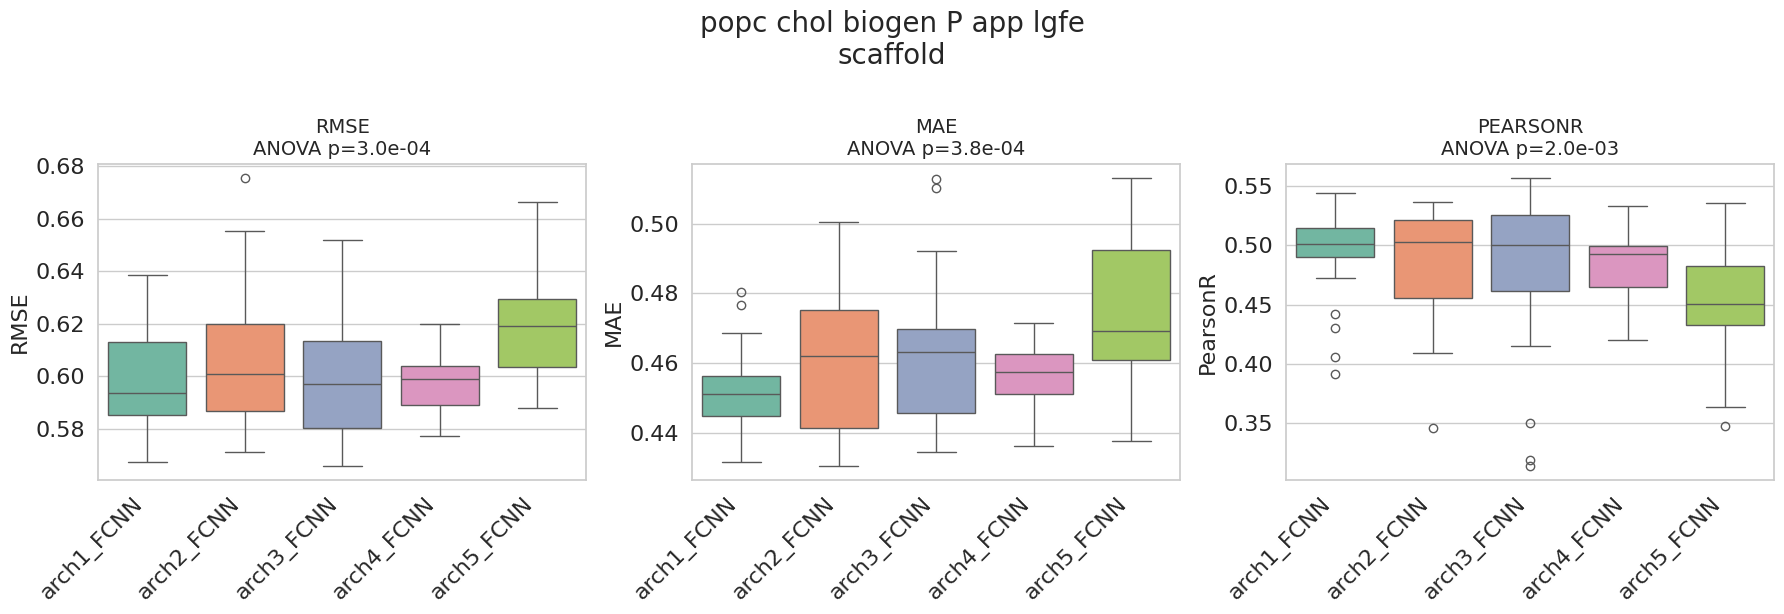

/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


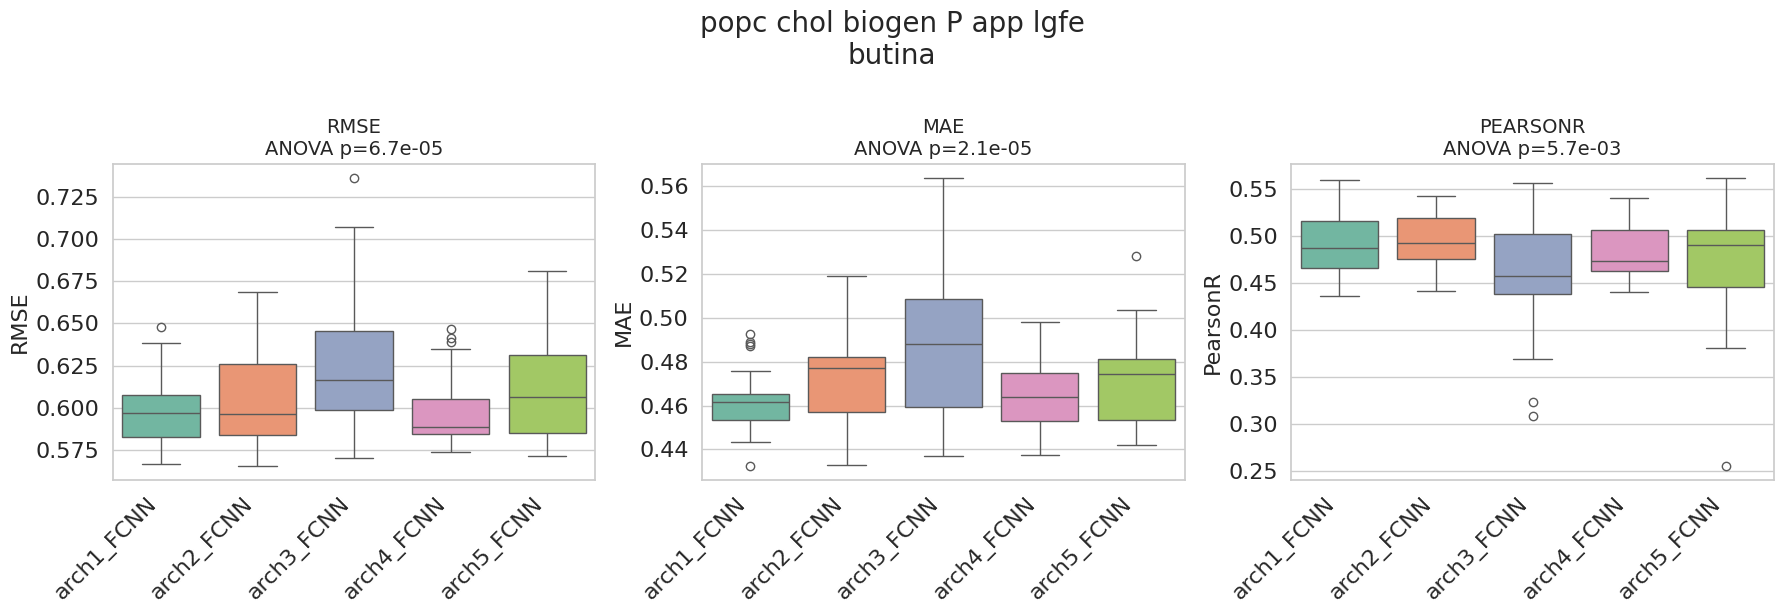

/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_49058/3014059538.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


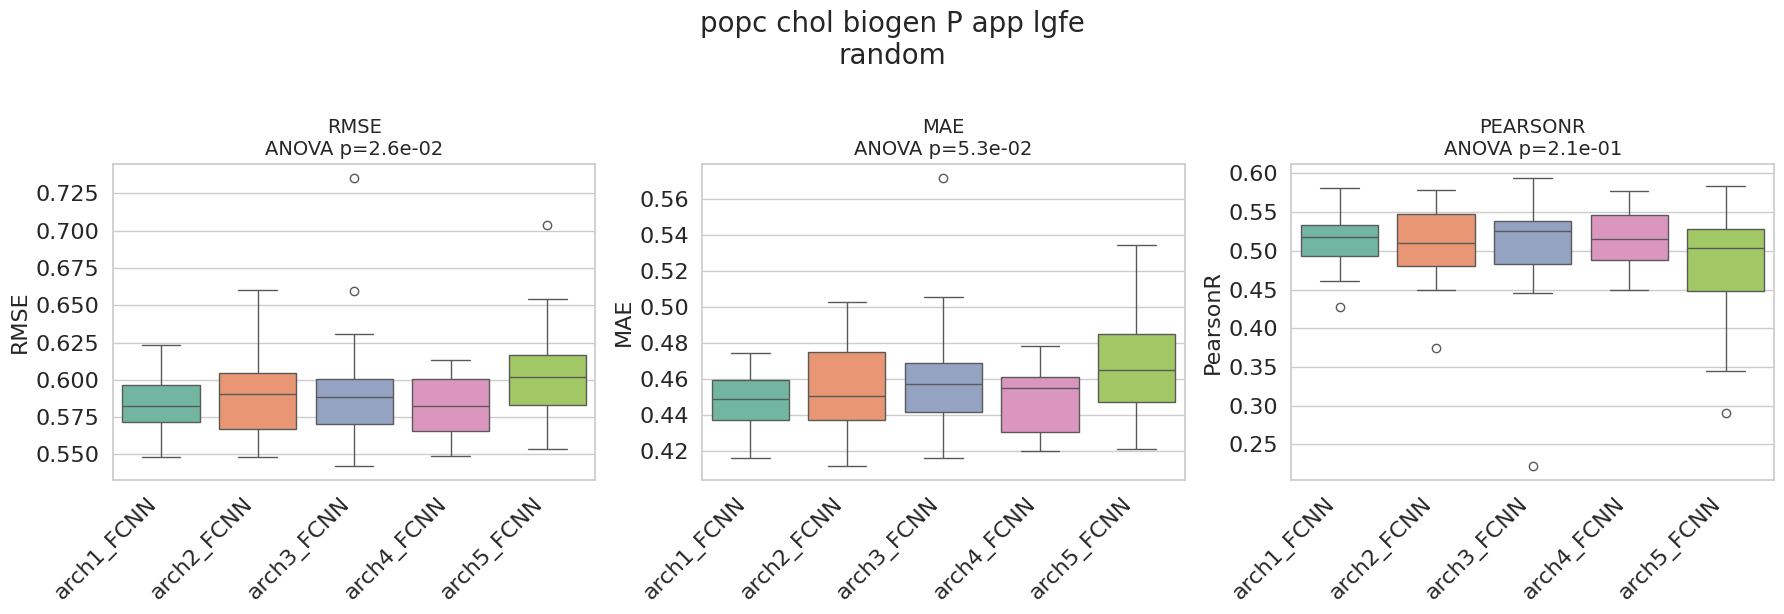

In [7]:
### Parametric boxplots (Sanity Check)
# test_df.query("split == 'scaffold'")
metric_ls = ['RMSE', 'MAE', 'PearsonR']
split_ls = ['scaffold', 'butina', 'random']

for split in split_ls:
    make_boxplots_parametric(test_df.query("split == '" + split + "'"), metric_ls,prefix=split)

evaluation_popc_chol.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.003214     12.765697
1     butina         RMSE       0.044519      3.675457
2     butina          MAE       0.000740      4.980671
3     butina     PearsonR       0.098219      4.611222
4     butina  SpearmanRho       0.037608      6.636098
5     random           R2       0.014554     12.265983
6     random         RMSE       0.271235      4.143689
7     random          MAE       0.175155      3.886802
8     random     PearsonR       0.197367      4.265839
9     random  SpearmanRho       0.061667      9.880387
10  scaffold           R2       0.065617      4.259125
11  scaffold         RMSE       0.034309      5.241364
12  scaffold          MAE       0.000159      5.707611
13  scaffold     PearsonR       0.245551      4.160556
14  scaffold  SpearmanRho       0.021811      8.960790
evaluation_popc_chol_halogen.csv
       split       metric  levene_pvalue  max_over_min
0     b

/tmp/ipykernel_49058/3887699841.py:295: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


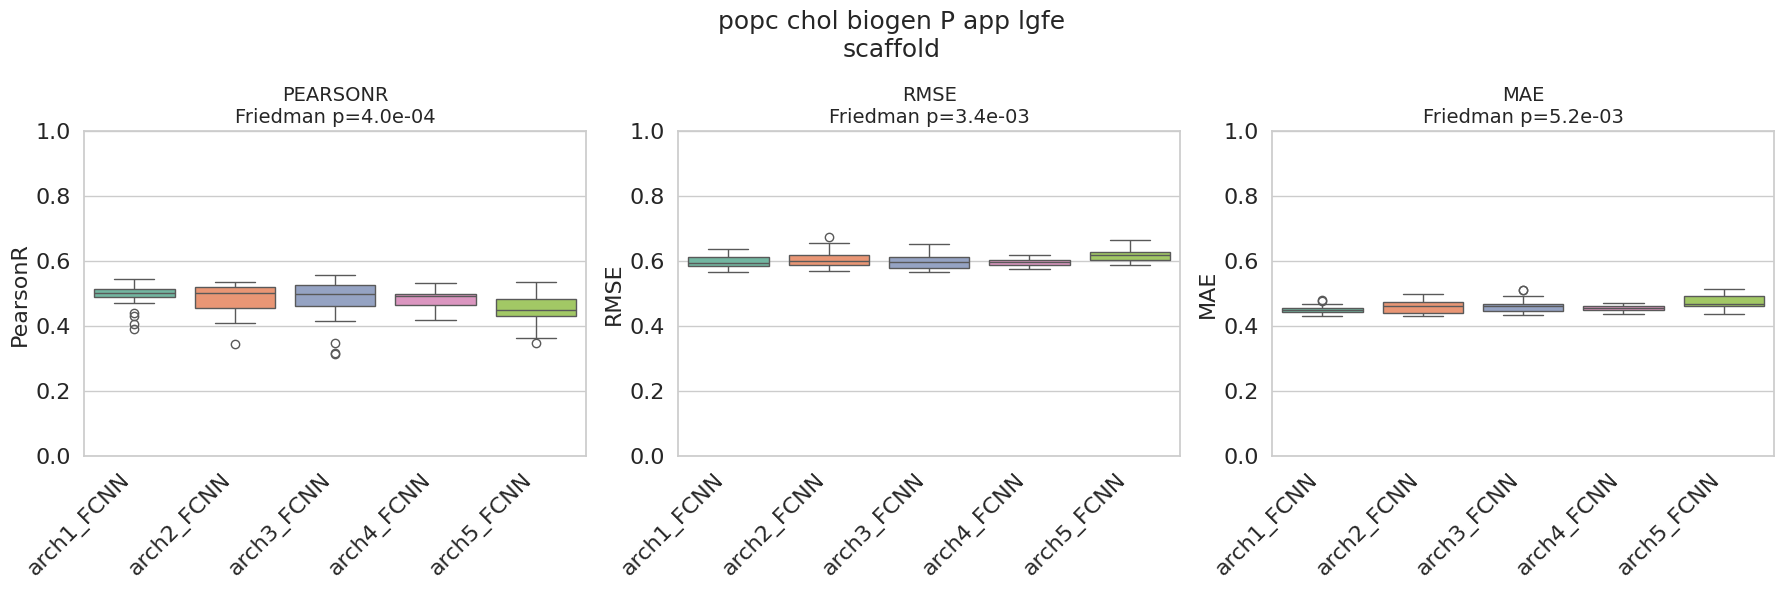

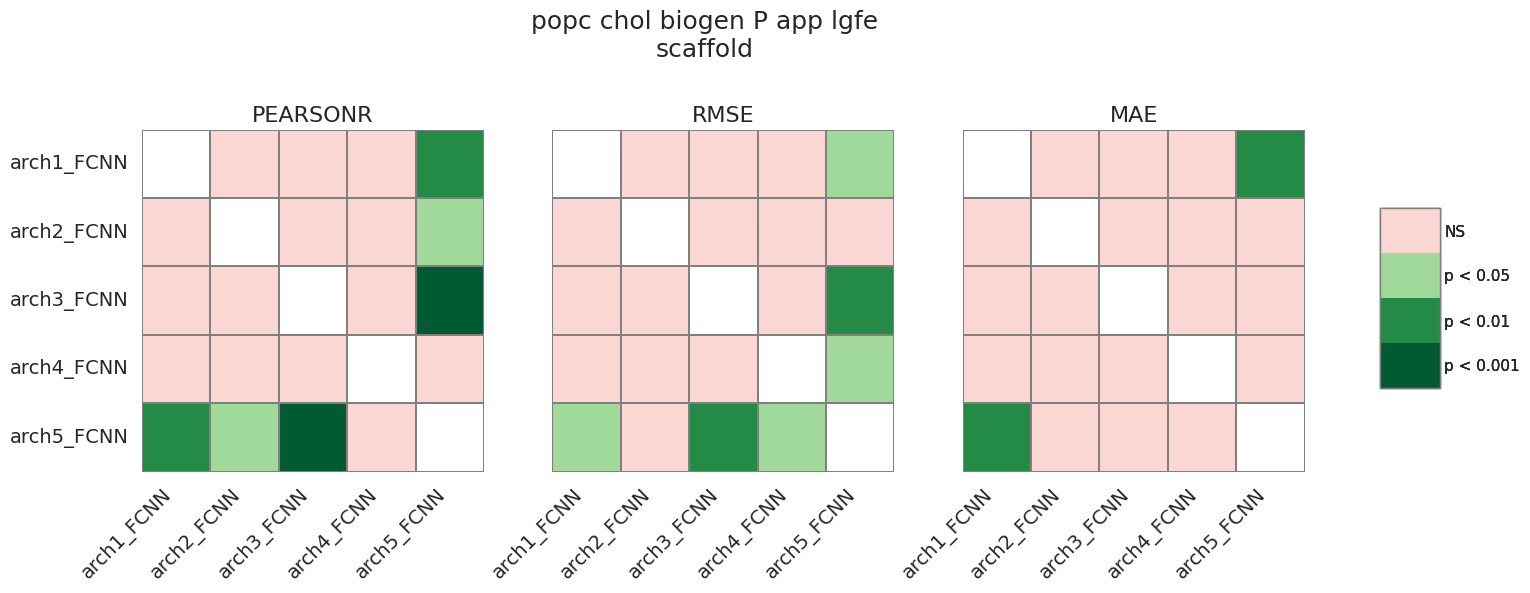

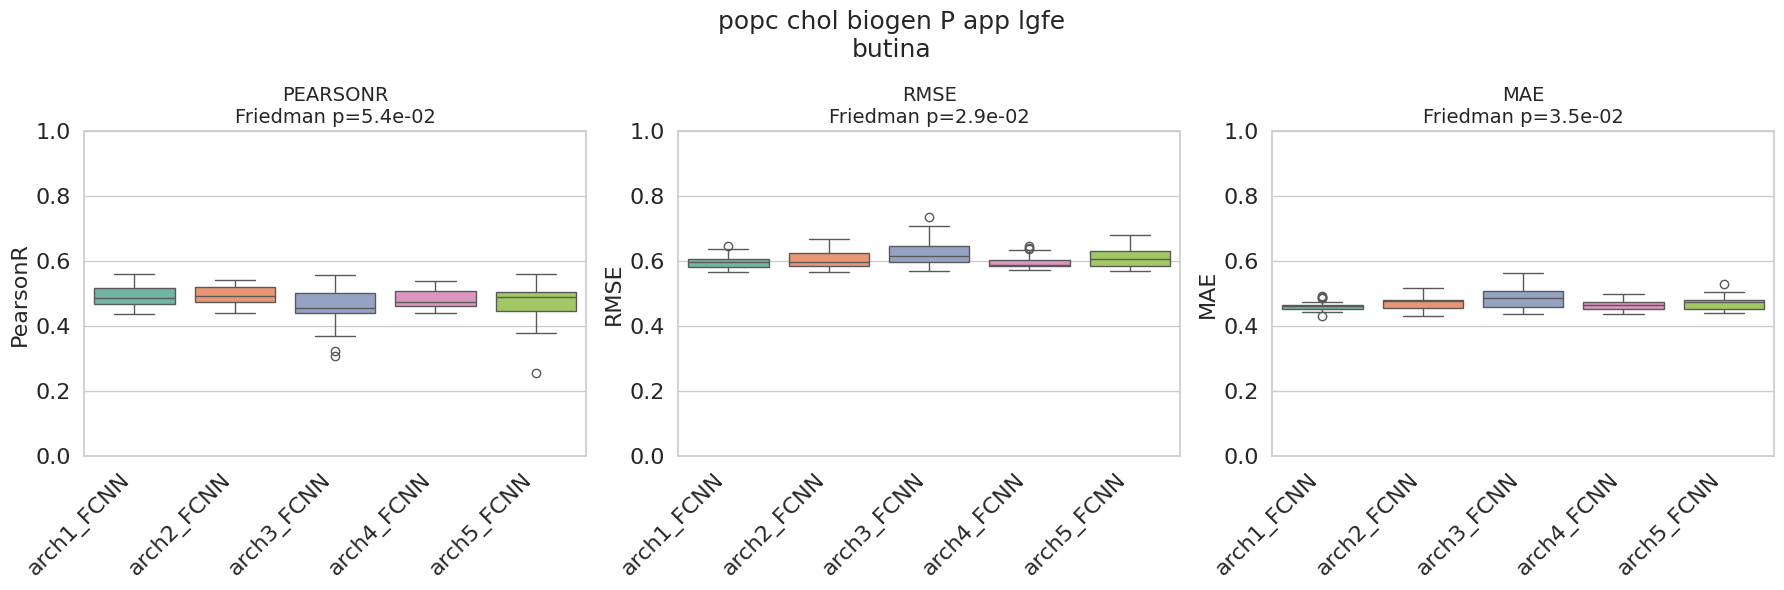

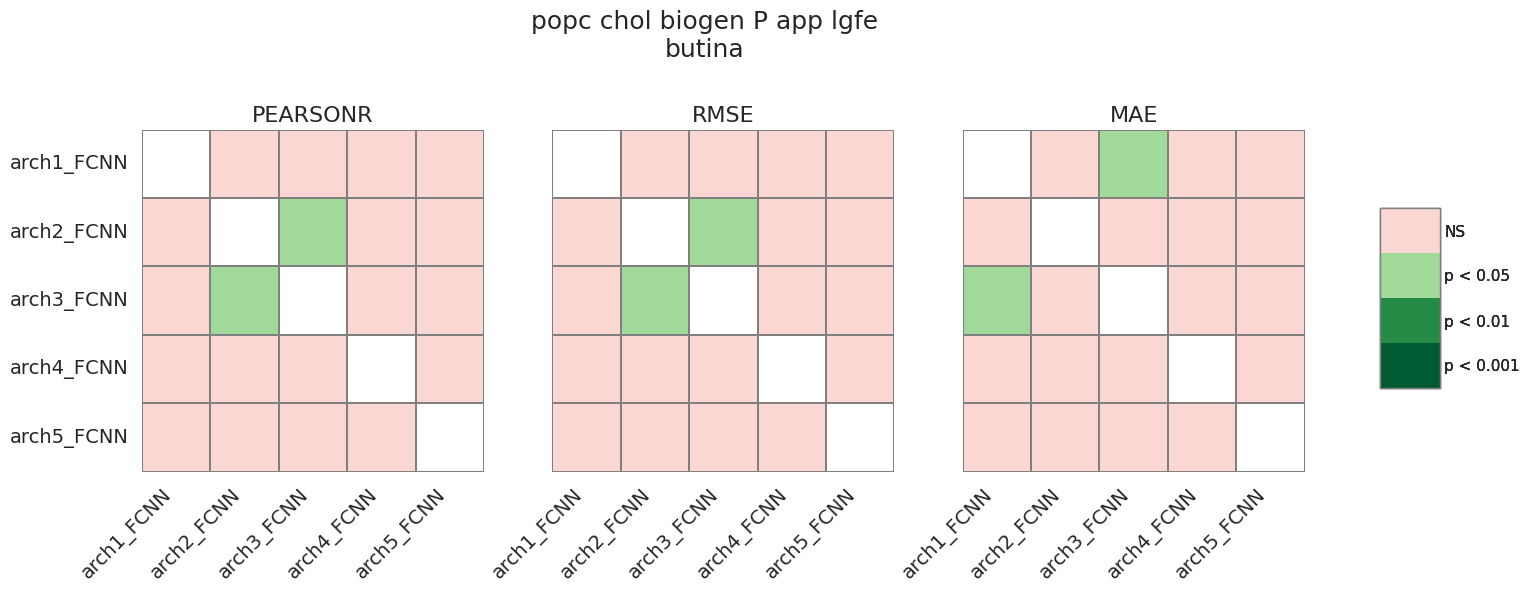

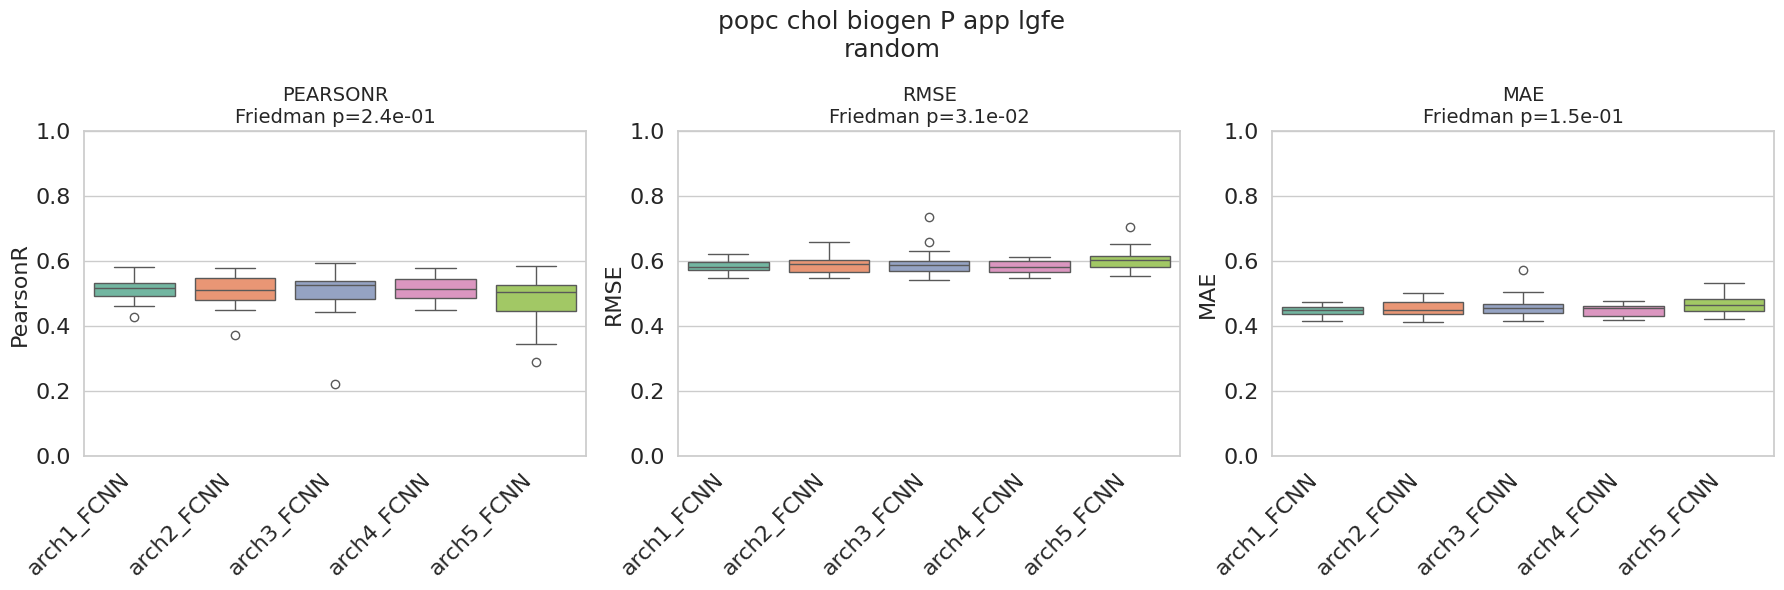

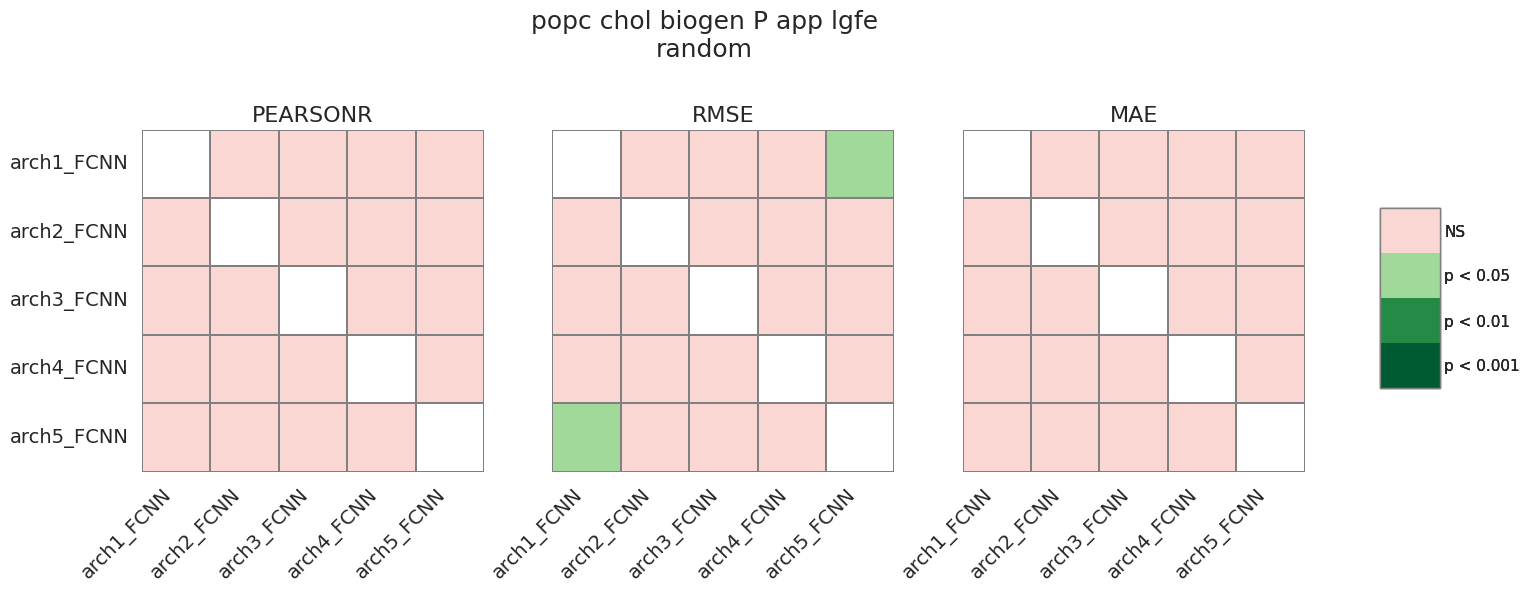

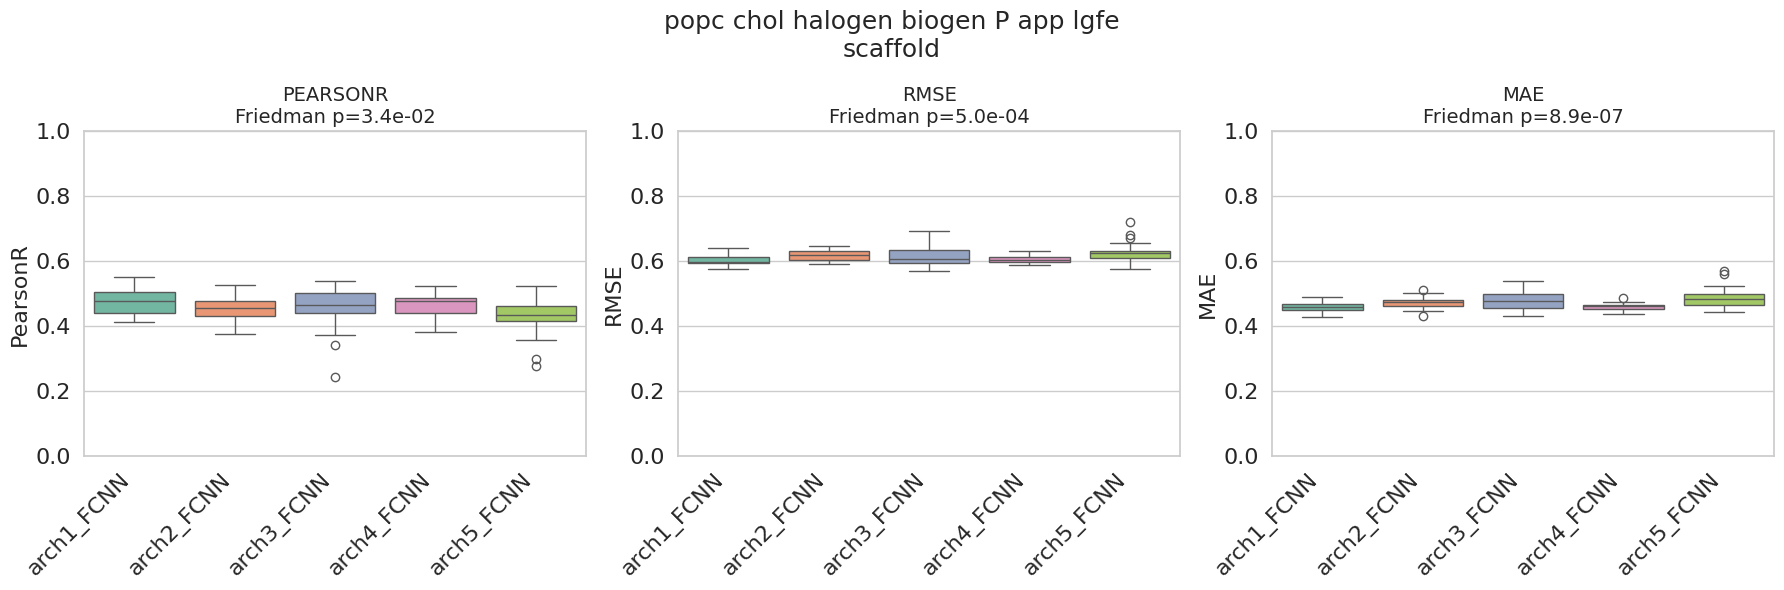

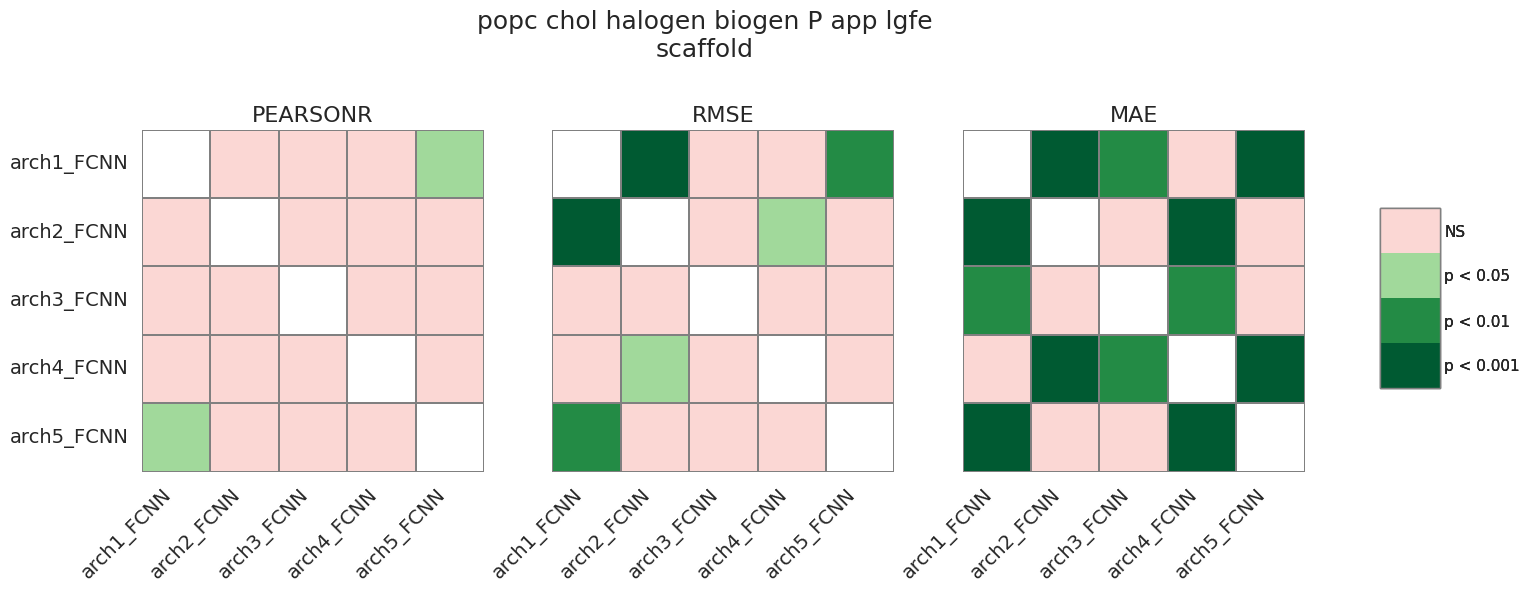

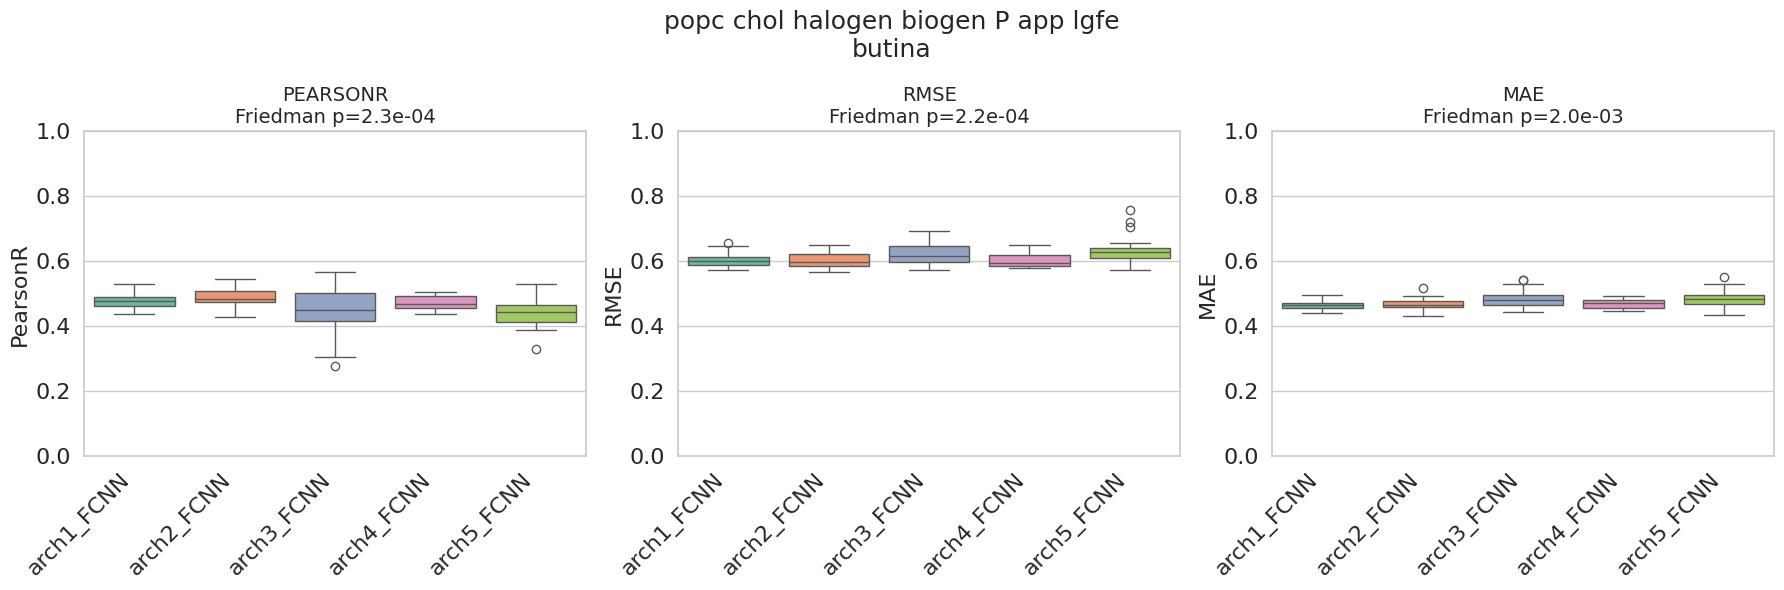

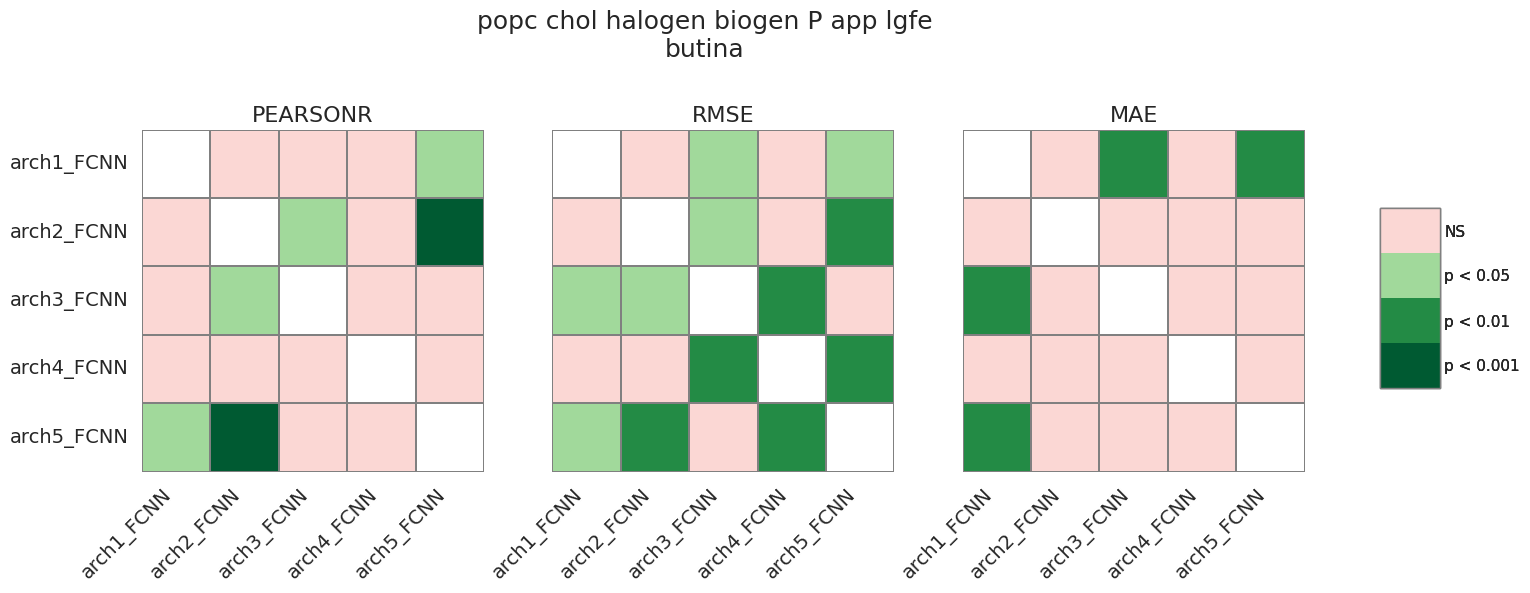

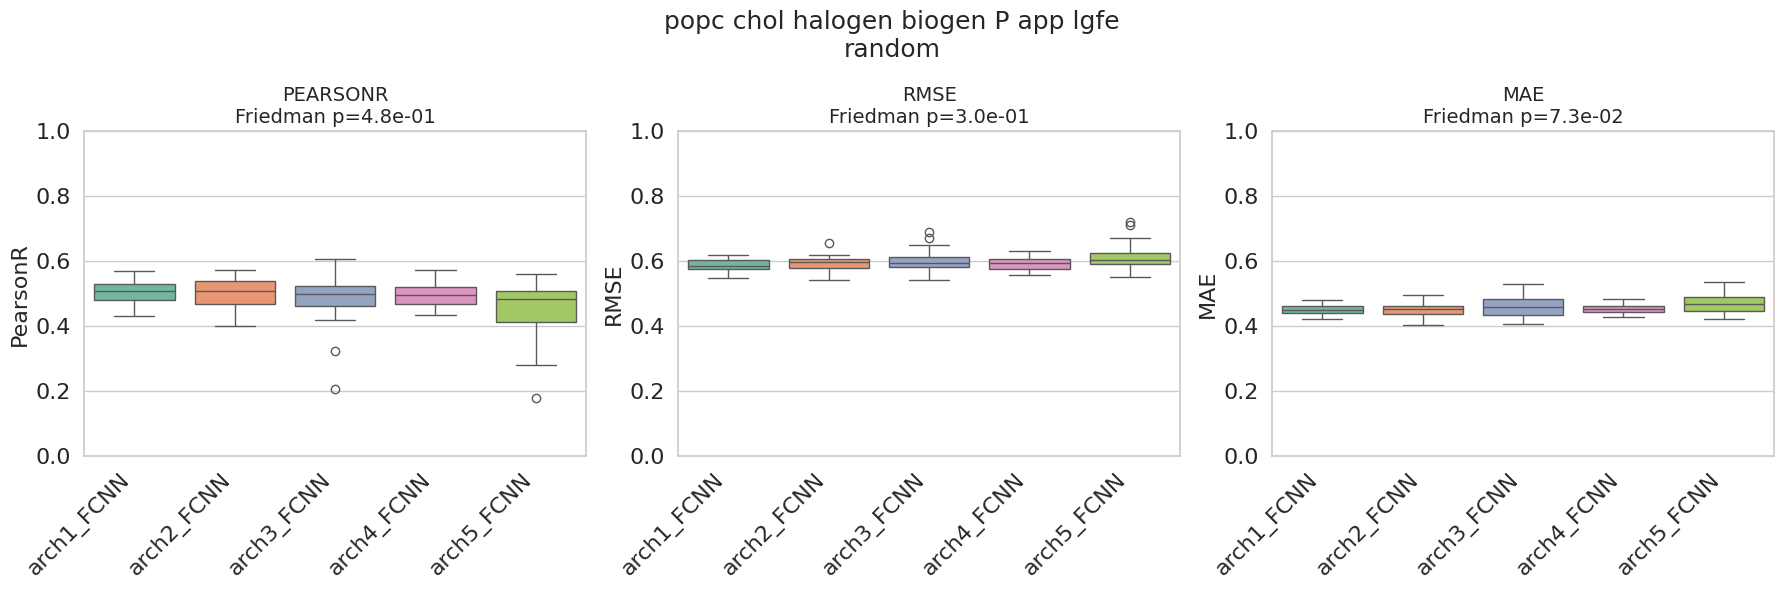

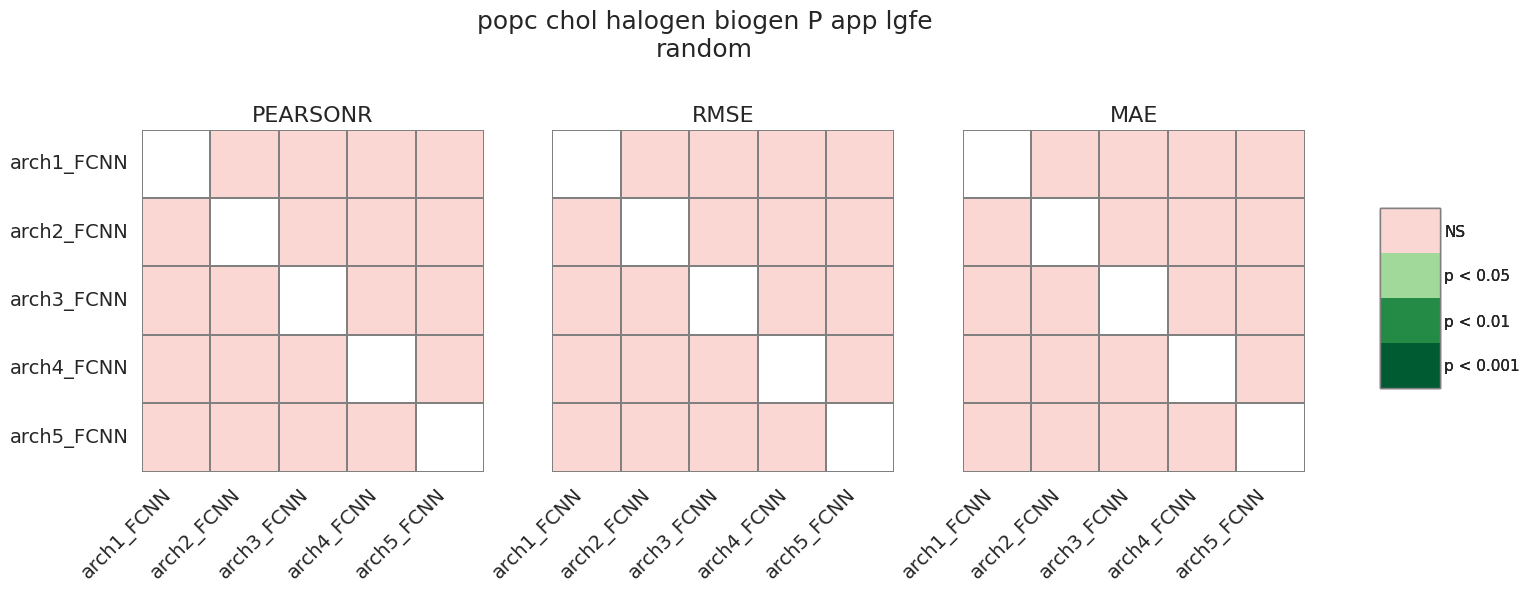

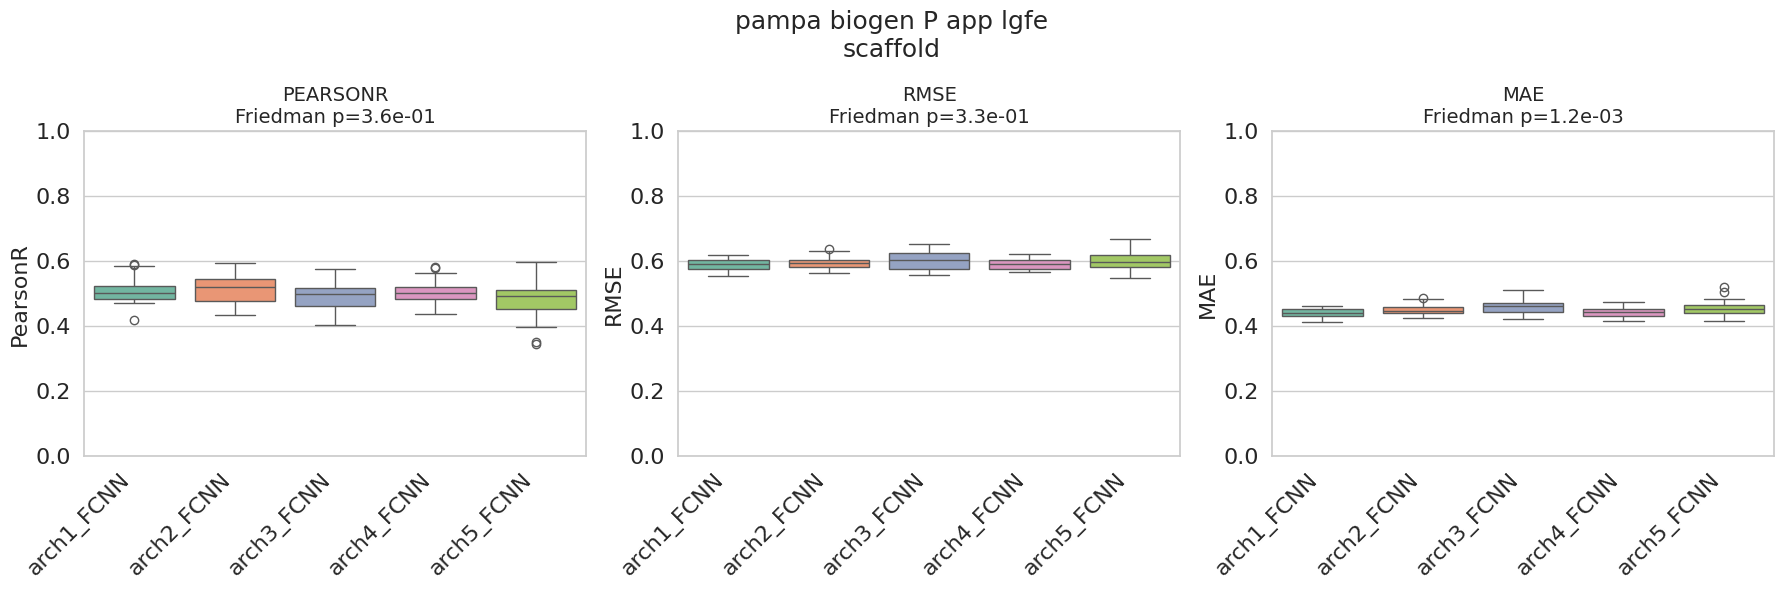

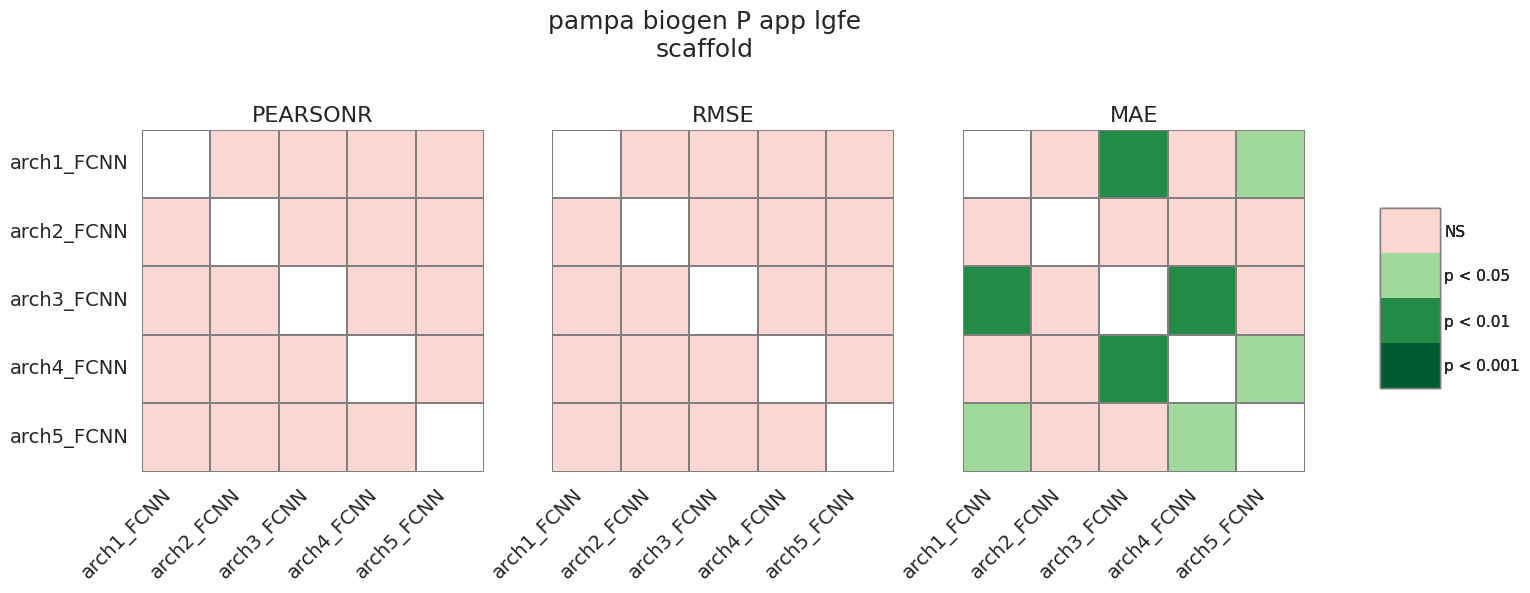

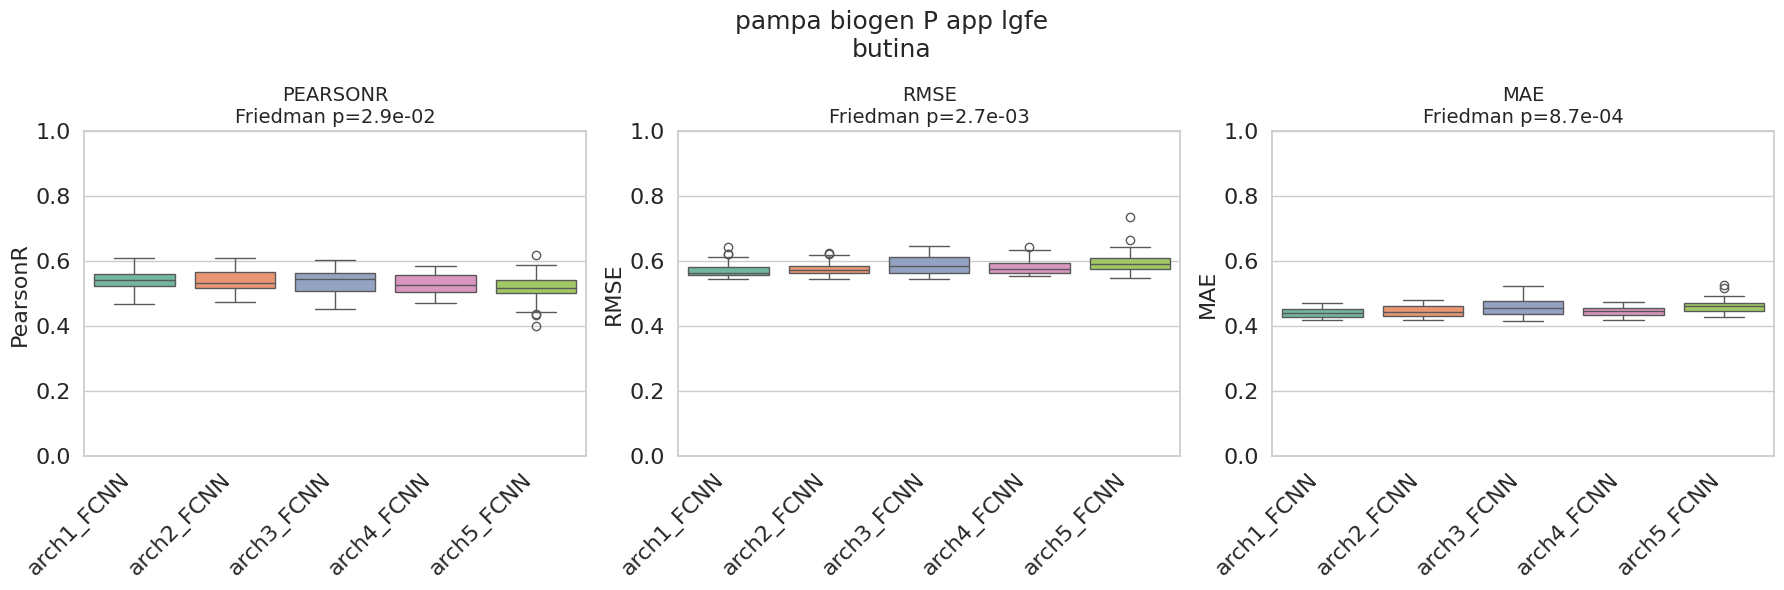

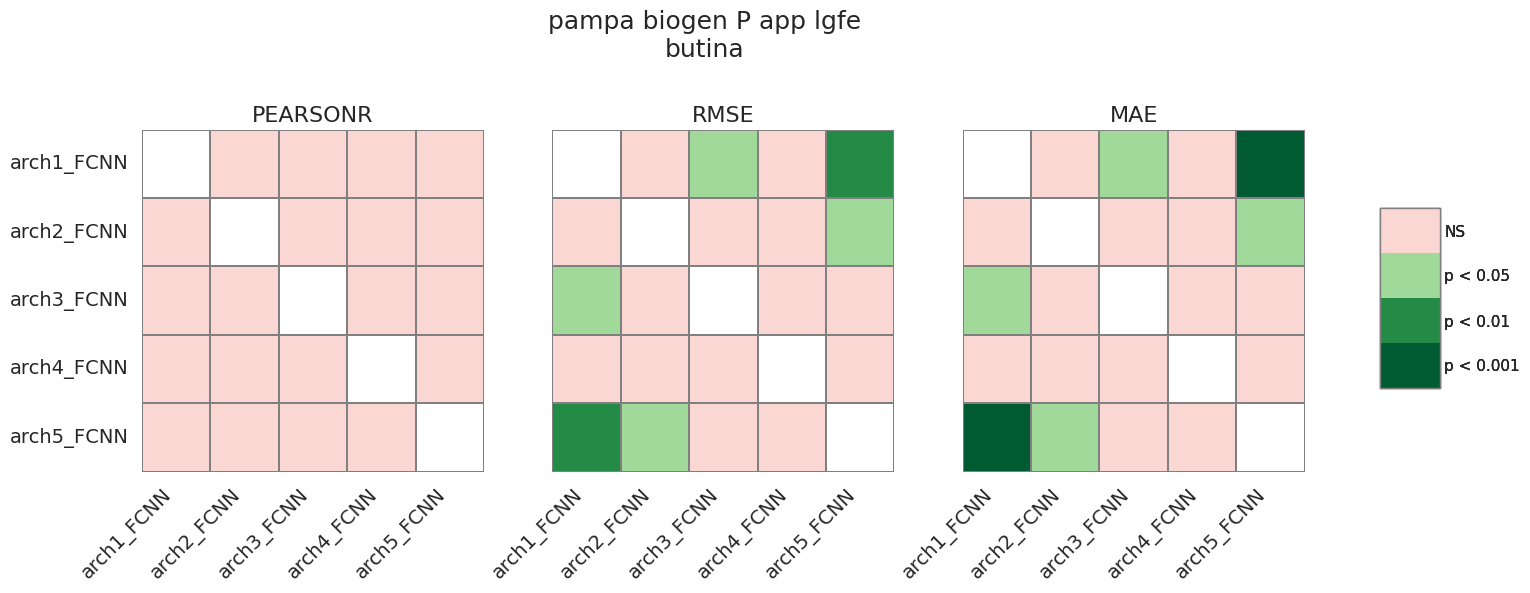

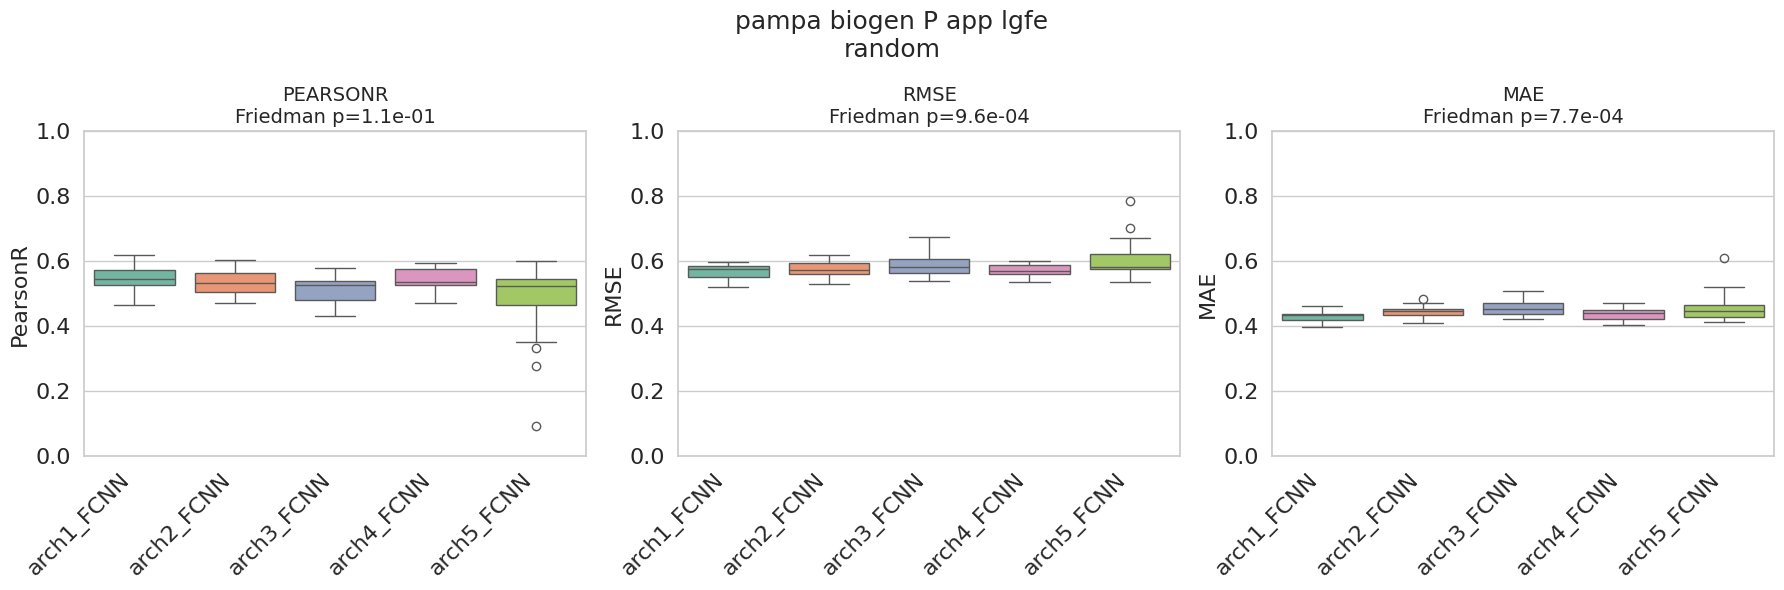

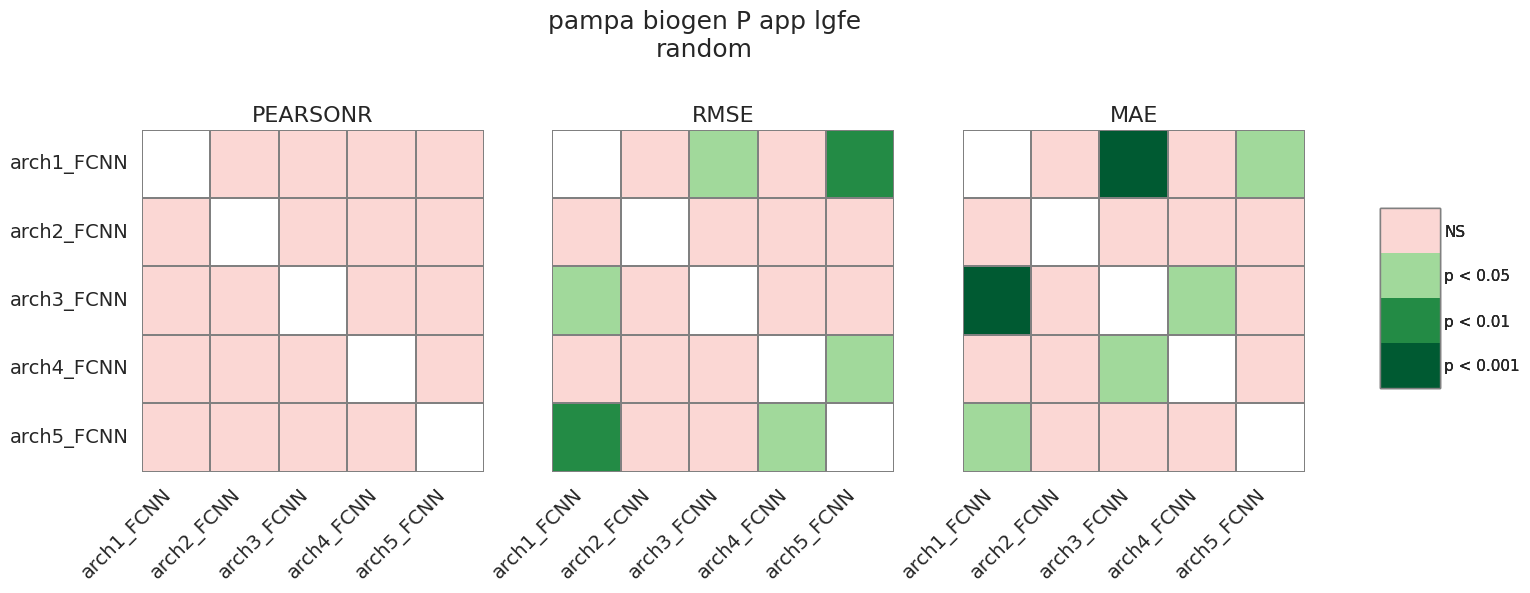

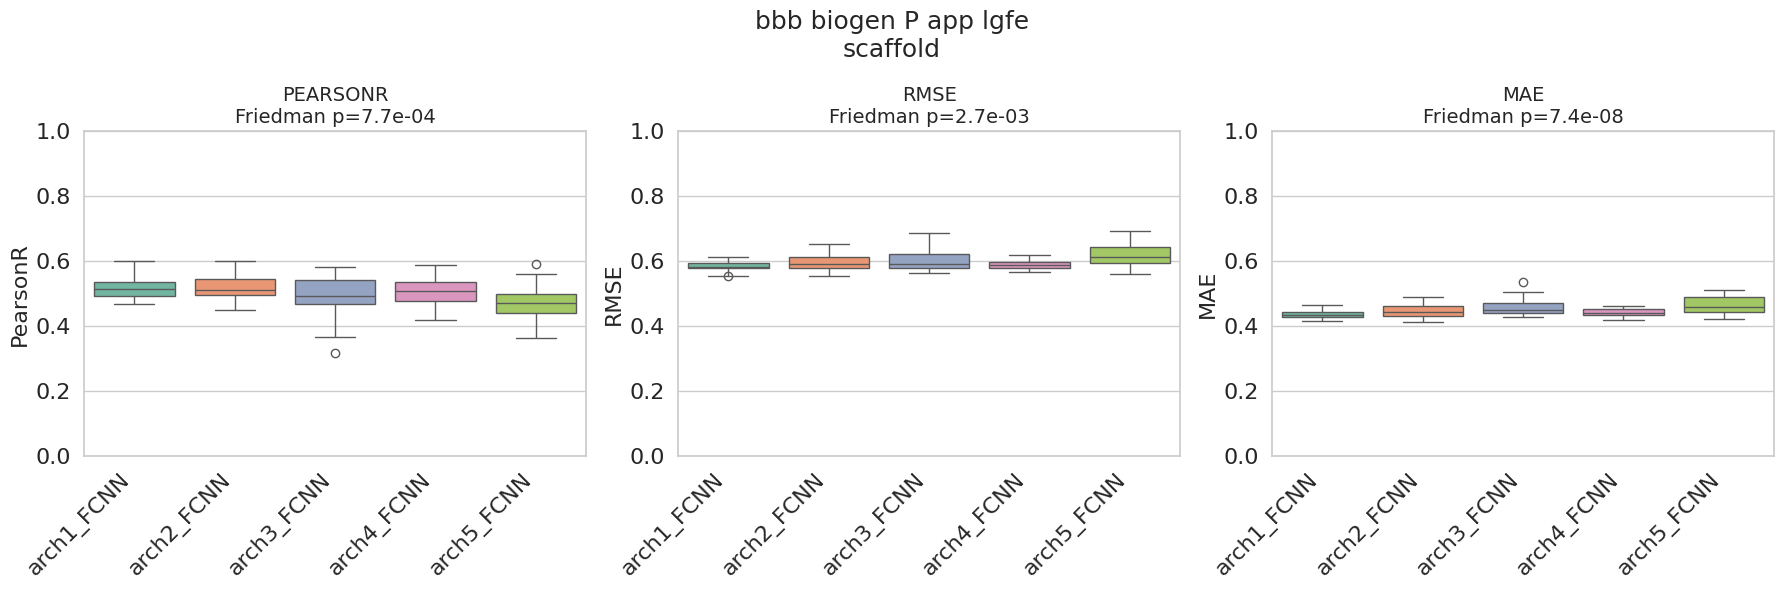

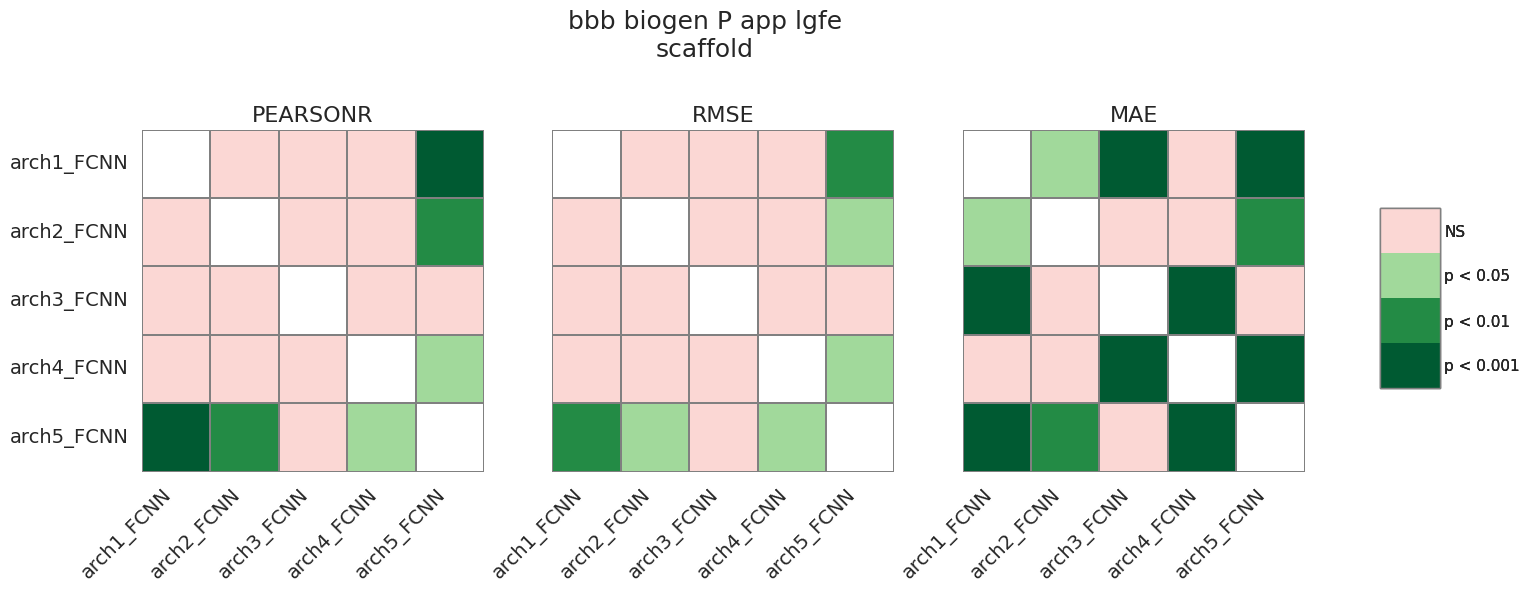

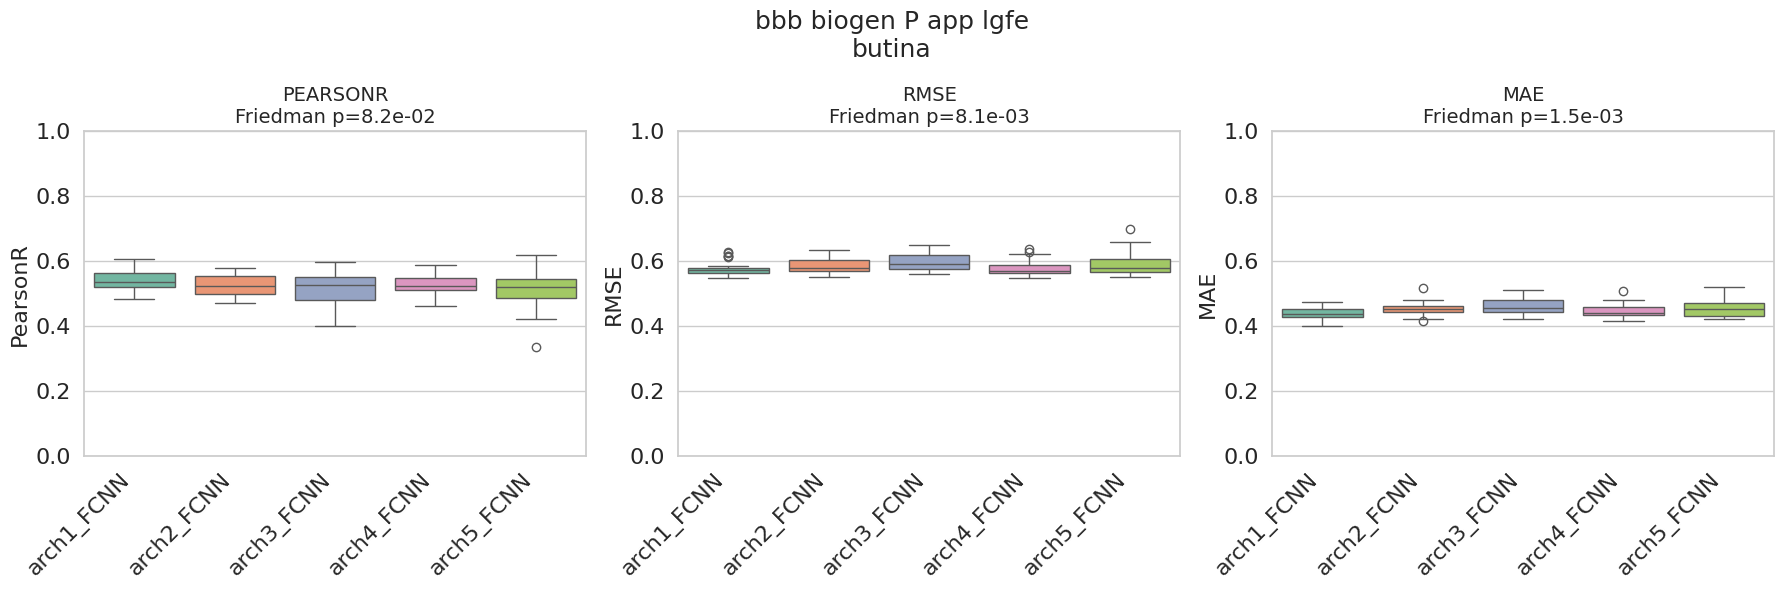

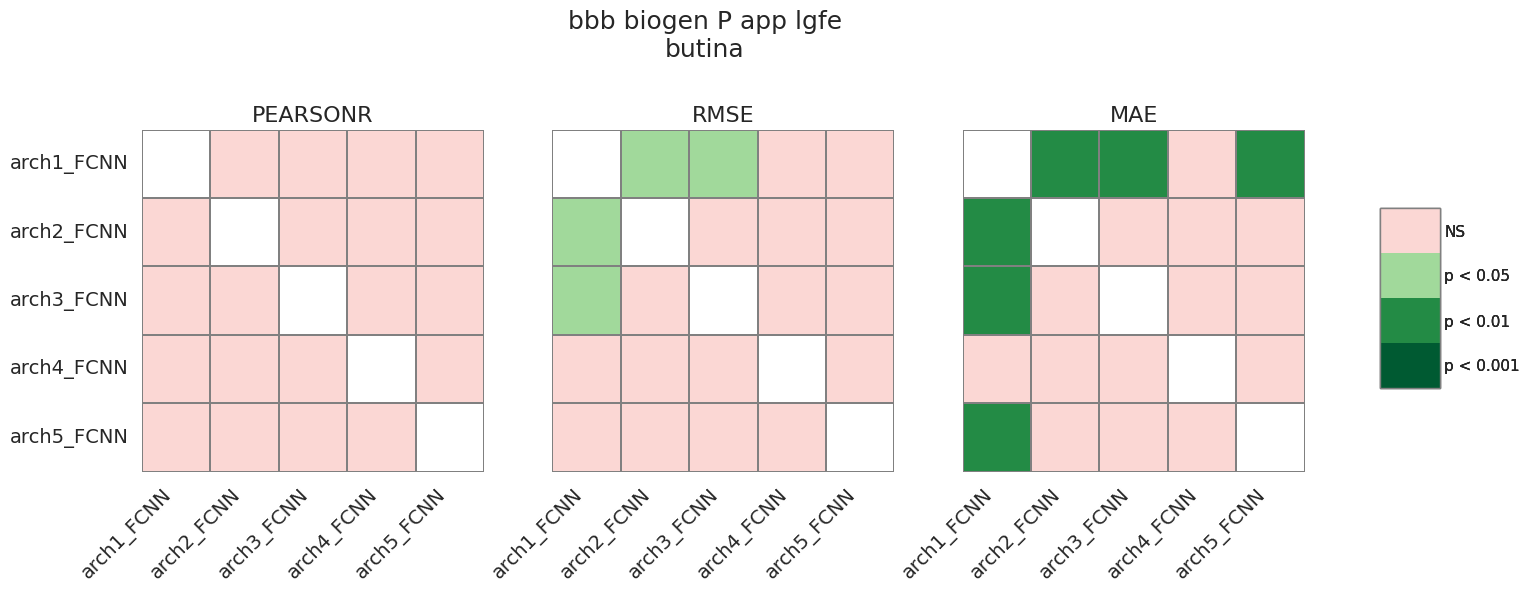

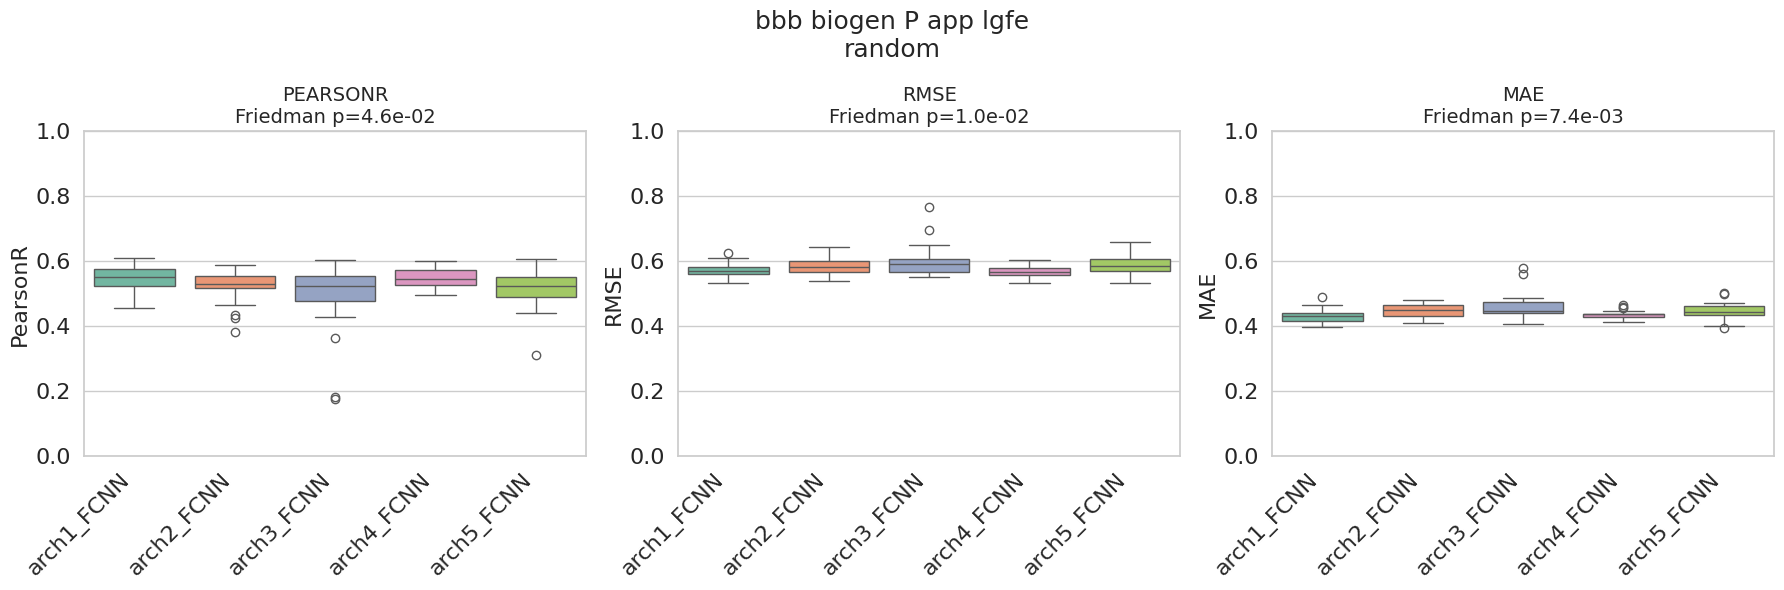

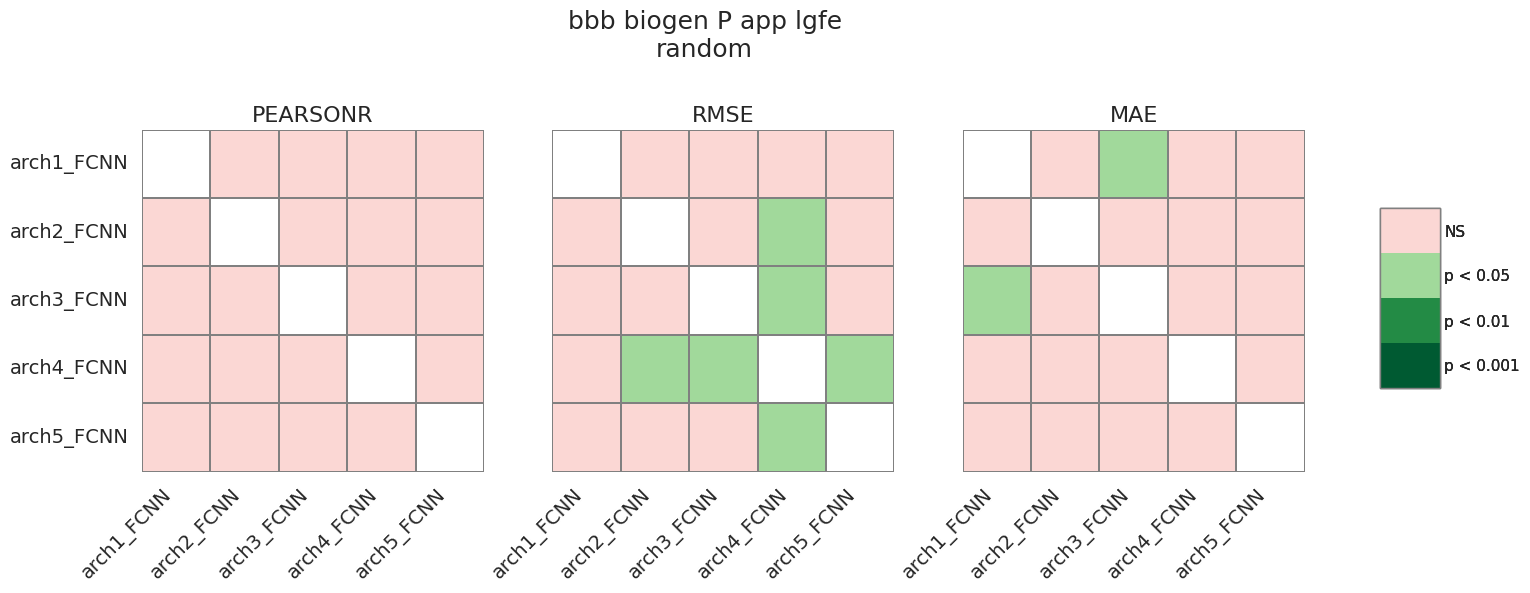

In [40]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./across_fcnn_archs")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./across_fcnn_archs")

/tmp/ipykernel_49058/3539028716.py:465: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


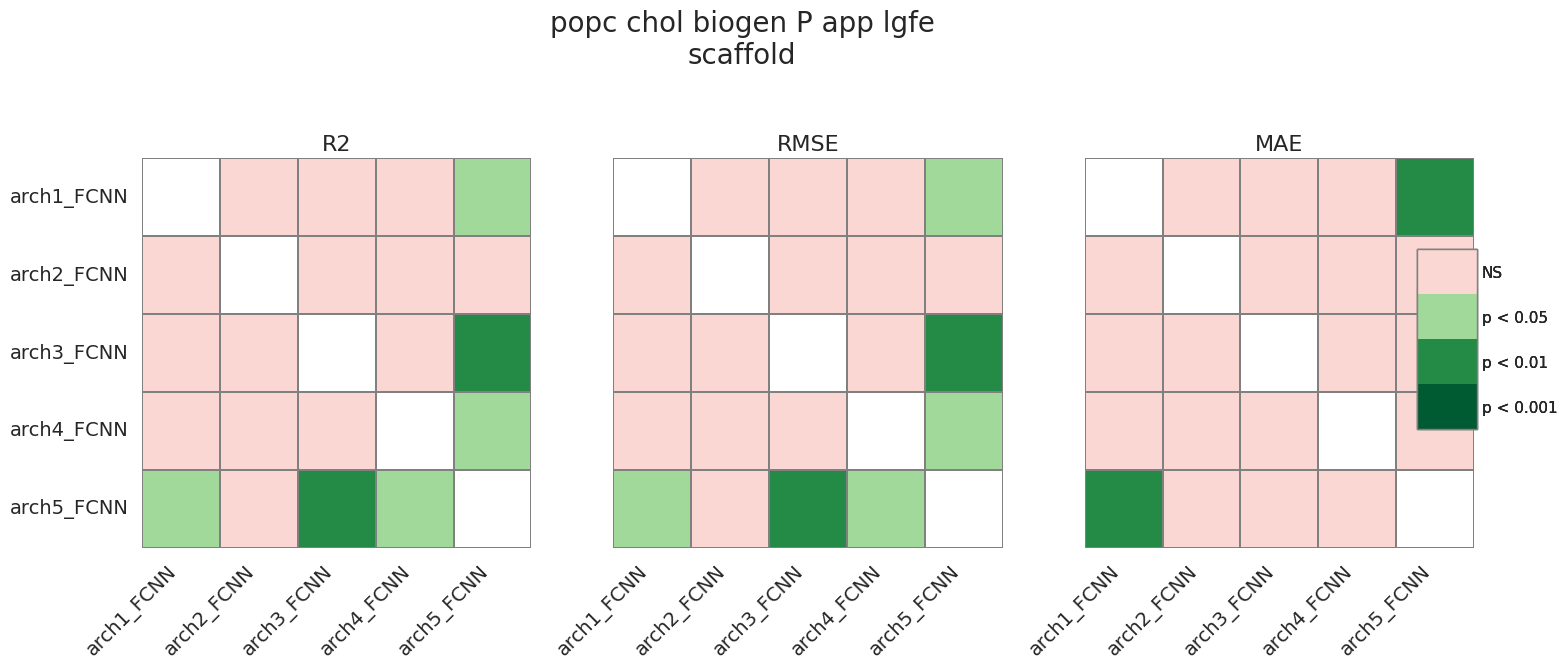

/tmp/ipykernel_49058/3539028716.py:465: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


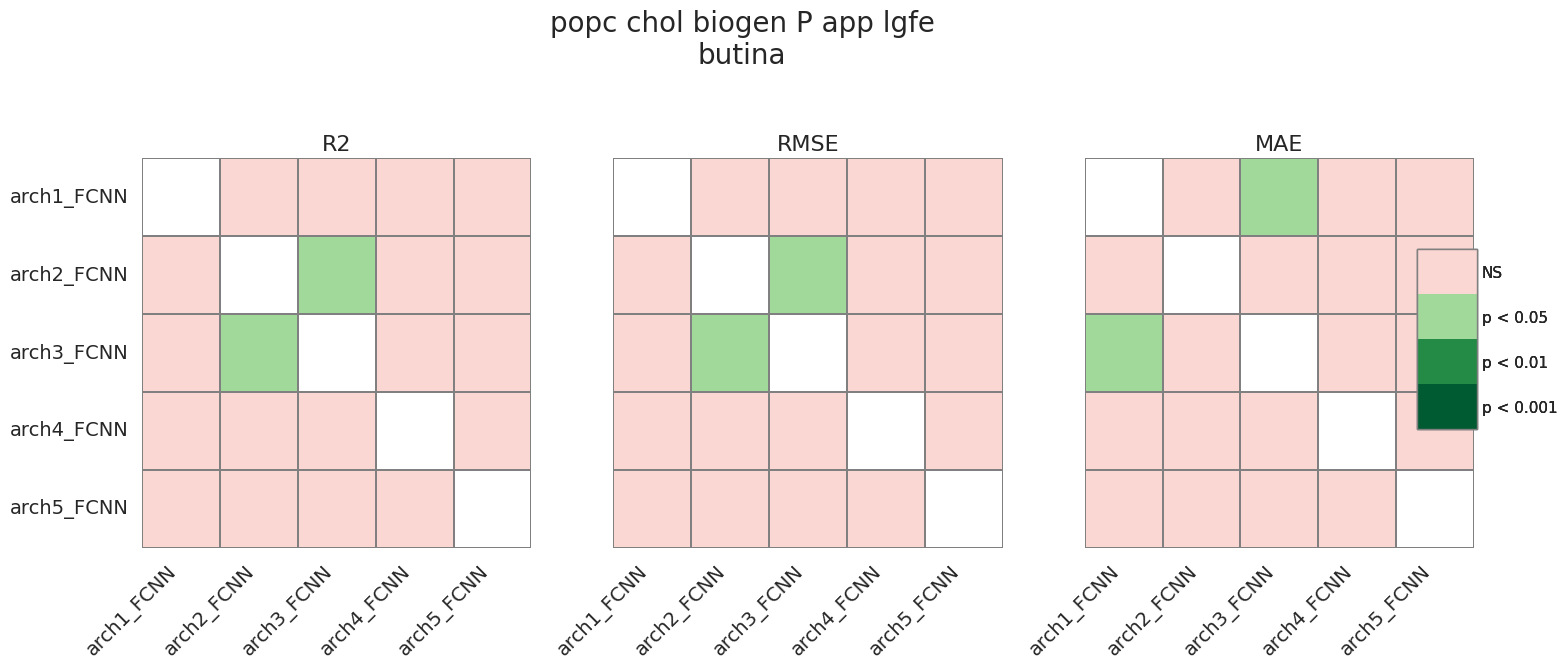

/tmp/ipykernel_49058/3539028716.py:465: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


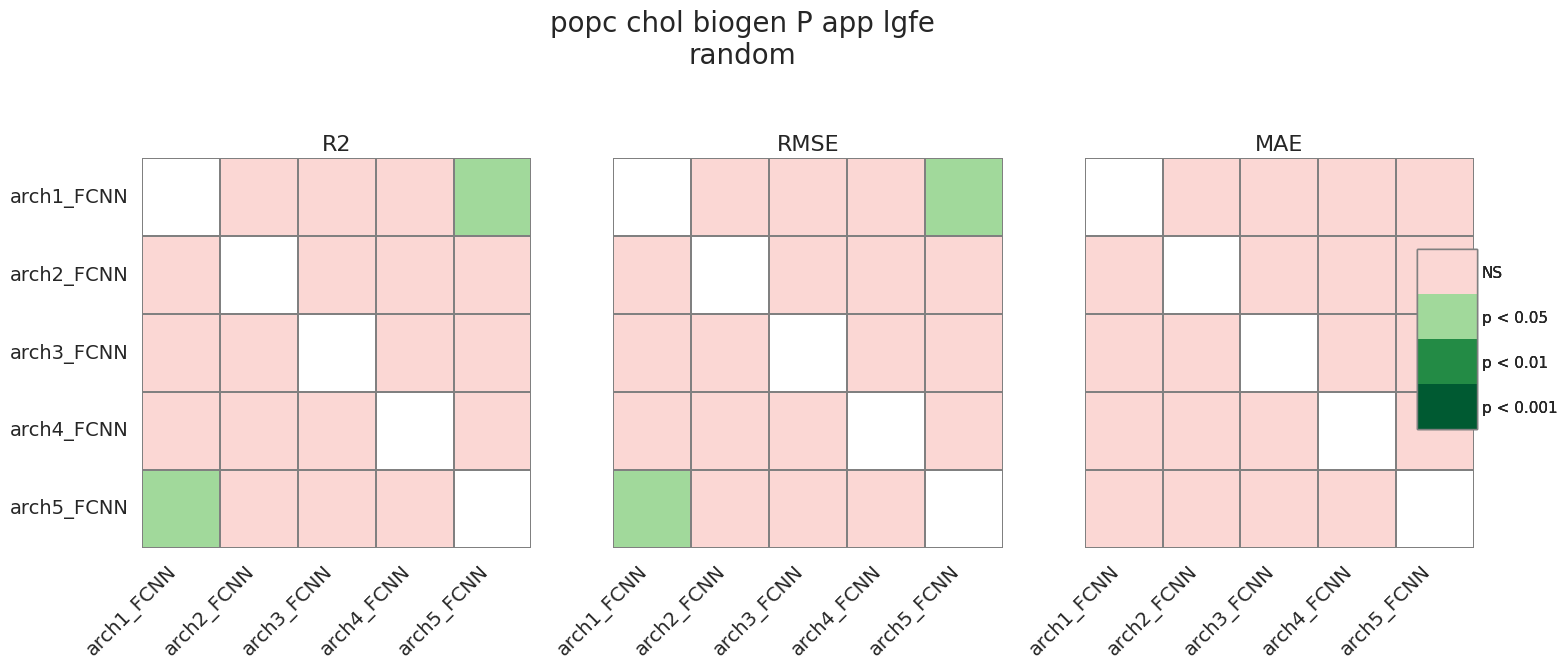

In [10]:
metric_ls = ['R2', 'RMSE', 'MAE']
for split in split_ls:
    